# Unsupervised Learning and Feature Engineering Project based on OSMI Mental Health in Tech Survey

### Introduction 
Mental health has become a topic of conversation across many industries. Companies have realised how their employees' wellbeing may affect their work performances. It is important for them to understand what factors may influence their mental health, and most importantly, what can be done to prevent or alleviate its effects. 

In this project, the OSMI Mental Health in Tech dataset (2016) containing answers from 1428 respondents will be analysed to categorise participants based on their answers. 

### Goals of the project: 
- present the data preparation process and feature engineering from the dataset mentioned above
- apply dimensionality reduction techniques such as PCA and MDS
- present visual interpretation of the results
- show unsupervised learning approach - KMeans clustering 
- present findings of the analysis and suggest recommendations for HR

### Steps of the project: 
1. Obtaining the data from kaggle.com. 
2. Data Exploration
3. Data Preprocessing and Feature Engineering
4. Feature Selection
5. Principal Component Analysis
6. Multidimensional Scaling
7. KMeans Clustering
8. Cluster Visualisation
9. Descriptive Statistics
10. Conclusions
11. Limitations
12. Future Work 

### Limitations of the data
The dataset presented below consist of many columns with missing values that must have been removed in the preprocessing phase. Moreover, the survey was performed within the Tech sector. In order to get broader results, obtaining another dataset might be valuable as it would enrich the analysis, and the results could be compared to add the validity. 

# 1. Obtaining the data
First, the necessary libraries and packages were installed in the local environment. The libraries and packages used in this project are listed below: 
- pandas - for managing datasets
- numpy - used in statistics and calculation 
- matplotlib and seaborn - for data visualisation 
- sklearn - used for scaling, feature extraction, PCA, MDS and clustering 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# used for textual feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.decomposition import PCA

from sklearn.manifold import MDS

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style('darkgrid')

In [2]:
# obtaining the file and saving it as mh_df (mh: mental health)
mh_df = pd.read_csv('mental_health.csv')

# 2. Exploratory data analysis 
In this section, the analysis of the dataset was conducted, to get a broader and deeper understanding of it. The results are presented below.

In [3]:
mh_df.shape

(1433, 63)

As shown above, the data set has 1433 rows and 63 columns. The latter are the features. 

In [4]:
# checking the general statistics of the dataset 
mh_df.describe(include="all")

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
count,1433.000000,1146,1146.000000,263.000000,1146,1013,1146,1146,1146,1146,...,1433,1433,1433.000000,1430,1433,840,1433,851,1433,1433
unique,NaN,6,NaN,NaN,4,3,3,3,3,6,...,5,5,NaN,70,53,47,53,48,264,3
top,NaN,26-100,NaN,NaN,Yes,No,No,No,I don't know,Somewhat easy,...,Not applicable to me,Often,NaN,Male,United States of America,California,United States of America,California,Back-end Developer,Sometimes
freq,NaN,292,NaN,NaN,531,354,813,531,742,281,...,557,538,NaN,610,840,130,851,141,263,757
mean,0.200279,NaN,0.770506,0.942966,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,34.286113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.400349,NaN,0.420691,0.232350,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,11.290931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,33.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Having the first glimpse at the dataset, it can be noticed that many columns have the number of unique features exceeding 5, some even reaching 264 and more. In the 'What is your age?' column, the minimum value is 3, and the maximum - 323, clearly indicating outliers. Additionally, the column 'What is your gender?' has 70 unique entries, suggesting 70 different genders. These issues affected the feature engineering decisions. 

In [5]:
# checking the data types of the columns 
mh_df.dtypes

Are you self-employed?                                                                 int64
How many employees does your company or organization have?                            object
Is your employer primarily a tech company/organization?                              float64
Is your primary role within your company related to tech/IT?                         float64
Does your employer provide mental health benefits as part of healthcare coverage?     object
                                                                                      ...   
What US state or territory do you live in?                                            object
What country do you work in?                                                          object
What US state or territory do you work in?                                            object
Which of the following best describes your work position?                             object
Do you work remotely?                                                 

In [6]:
# checking how many columns with object type are there 
mh_df.dtypes.value_counts()

object     56
int64       4
float64     3
Name: count, dtype: int64

As presented above, 56 out of 63 features are categorical/textual. 

In the next step, the missing values in the dataset were examined. 

In [7]:
# checking the number and percentage of the missing value in each column 
missing_values = mh_df.isnull().sum()
missing_perc = (missing_values/len(mh_df)*100).round(1) 

# creating a new data frame for visual purposes 
missing_values_df = pd.DataFrame({'missing values': missing_values, 'missing percentage':missing_perc})
missing_values_df = missing_values_df[missing_values_df['missing values'] > 0].sort_values('missing percentage', ascending=False)
missing_values_df


,missing values,missing percentage
"If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?",1289,90.0
"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",1229,85.8
Is your primary role within your company related to tech/IT?,1170,81.6
Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,1146,80.0
Do you believe your productivity is ever affected by a mental health issue?,1146,80.0
"If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",1146,80.0
"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?",1146,80.0
"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?",1146,80.0
Do you know local or online resources to seek help for a mental health disorder?,1146,80.0
"If maybe, what condition(s) do you believe you have?",1111,77.5


In [8]:
missing_values_df.shape

(44, 2)

To better understand the missing values, a heatmap was created below.

/var/folders/j2/mzg4562d1tldwwf84136fq8h0000gn/T/ipykernel_67901/2997541796.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


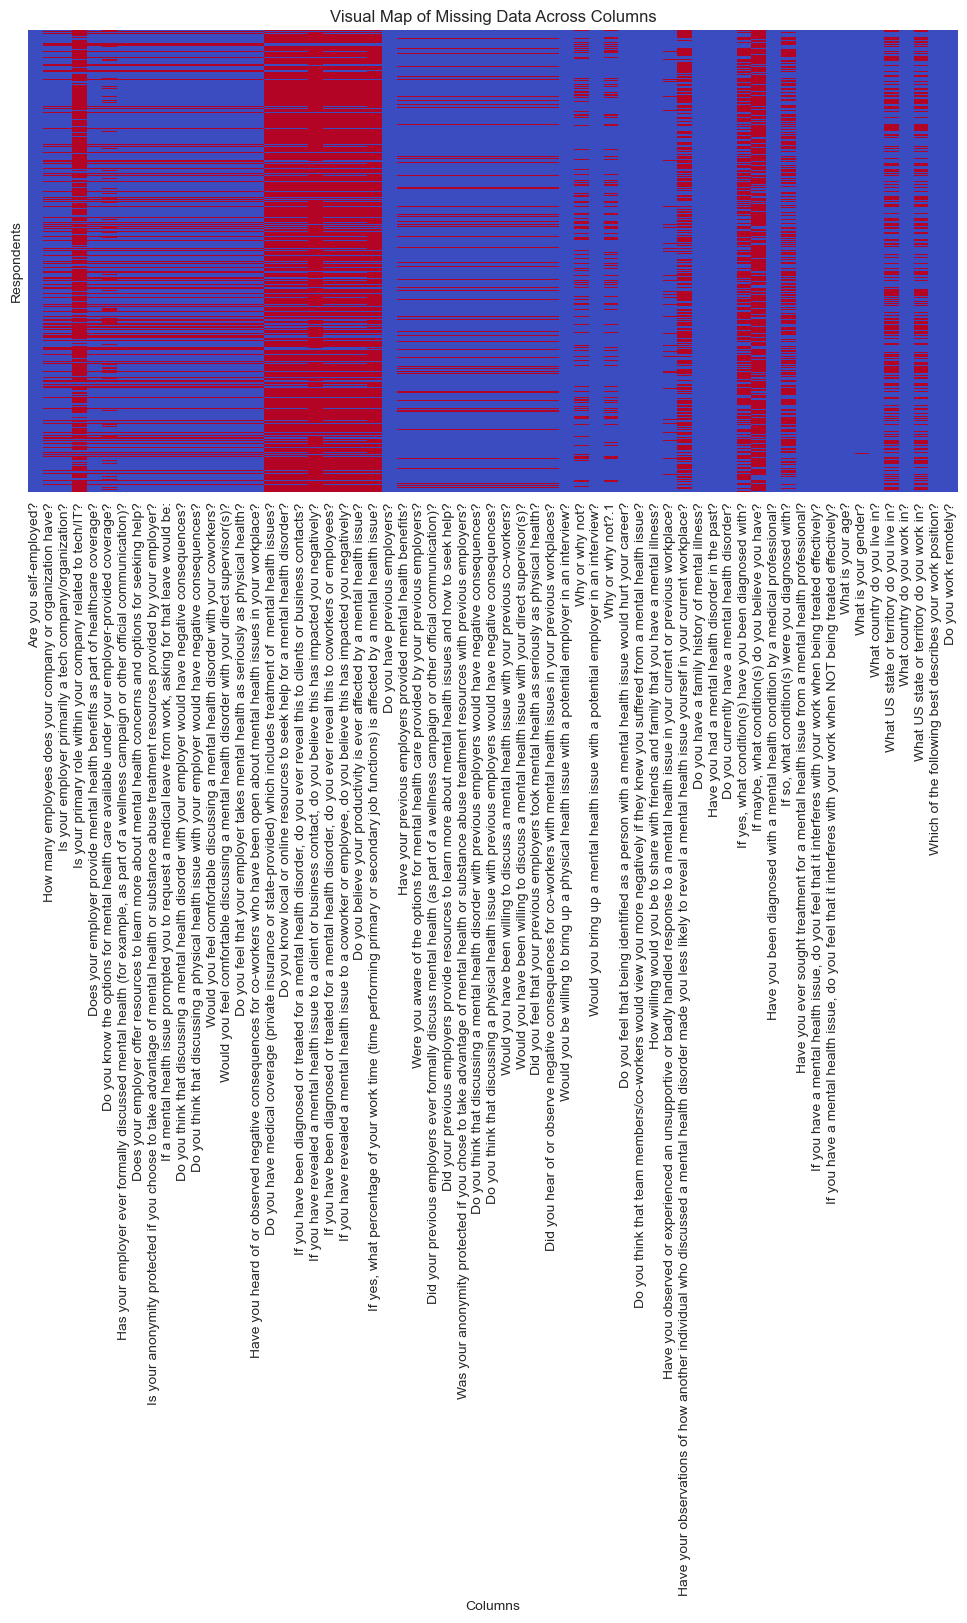

In [9]:
plt.figure(figsize=(12, 6))
sns.heatmap(mh_df.isnull(), cbar=False, yticklabels=False, cmap="coolwarm")

plt.title("Visual Map of Missing Data Across Columns")
plt.xlabel("Columns")
plt.ylabel("Respondents")
plt.tight_layout()
plt.show()

The red lines represent missing values. There is a systematic presence of high missing values across employer-related questions, f.e. 'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?'. This corresponds to the fact that self-employed people were not a subject to employer-related questions and could not answer them. The missingness pattern present here is consistent with 'Missing Not At Random' (MNAR). Based on this information, the category 'Unknown' was created to preserve information that the survey question was not answered. 

All of these 44 columns have some missing values. They were divided into 3 groups, based on the percentage of the missing values: 
- I: above 50% of the values missing - candidates for dropping them
- II: between 15% and 50% missing - candidates for creating another value: 'Unknown'
- III: below 15% missing - candidates for filling the missing values with the mode of the column 

In [10]:
# creating an overview dataframe containing information about the data type, missing values, and unique values of the columns as the reference point 
overview_df = pd.DataFrame({
'data type': mh_df.dtypes, 
'missing values': mh_df.isnull().sum(),
'missing percentage': (mh_df.isnull().sum() / len(mh_df) * 100).round(1),
'unique values': mh_df.nunique()
})
overview_df[overview_df["missing values"]>0].sort_values('missing values', ascending=False)

,data type,missing values,missing percentage,unique values
"If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?",object,1289,90.0,3
"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",object,1229,85.8,4
Is your primary role within your company related to tech/IT?,float64,1170,81.6,2
Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,float64,1146,80.0,2
Do you believe your productivity is ever affected by a mental health issue?,object,1146,80.0,4
"If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",object,1146,80.0,4
"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?",object,1146,80.0,5
"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?",object,1146,80.0,5
Do you know local or online resources to seek help for a mental health disorder?,object,1146,80.0,3
"If maybe, what condition(s) do you believe you have?",object,1111,77.5,99


In [11]:
# top columns with missing values percentage more than 50%
top_mv_columns = overview_df[overview_df["missing percentage"]>50].sort_values('missing percentage', ascending=False) 

# obtaining a list of the names of columns with over 50% missing values
top_mv_columns.index.to_list()

['If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?',
 'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?',
 'Is your primary role within your company related to tech/IT?',
 'Do you have medical coverage (private insurance or state-provided) which includes treatment of \xa0mental health issues?',
 'Do you know local or online resources to seek help for a mental health disorder?',
 'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?',
 'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?',
 'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?',
 'Do you believe your productivity is ever affected by a mental health issue?',
 'If

By looking at the columns' names with the most number of missing values, additionally to the previous findings, it can be seen that most of the questions with the missing values are conditional, starting with 'if' - this suggests that the number of missing values is high because in the previous questions, relative to these ones, the option 'it does not apply to me', or something similar was chosen. Moreover, the 4th column in the list has some special character in the name, which must be taken into account. 

In [12]:
missing_pct = overview_df[overview_df["missing values"]>0].sort_values('missing values', ascending=False)['missing percentage']

In [13]:
# created for differentiating the columns on the graph visually by different colours 
cols = ['#3379b9' if (col >= 50) else '#C1c8ce' for col in missing_pct]

/var/folders/j2/mzg4562d1tldwwf84136fq8h0000gn/T/ipykernel_67901/3257517461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette=cols)


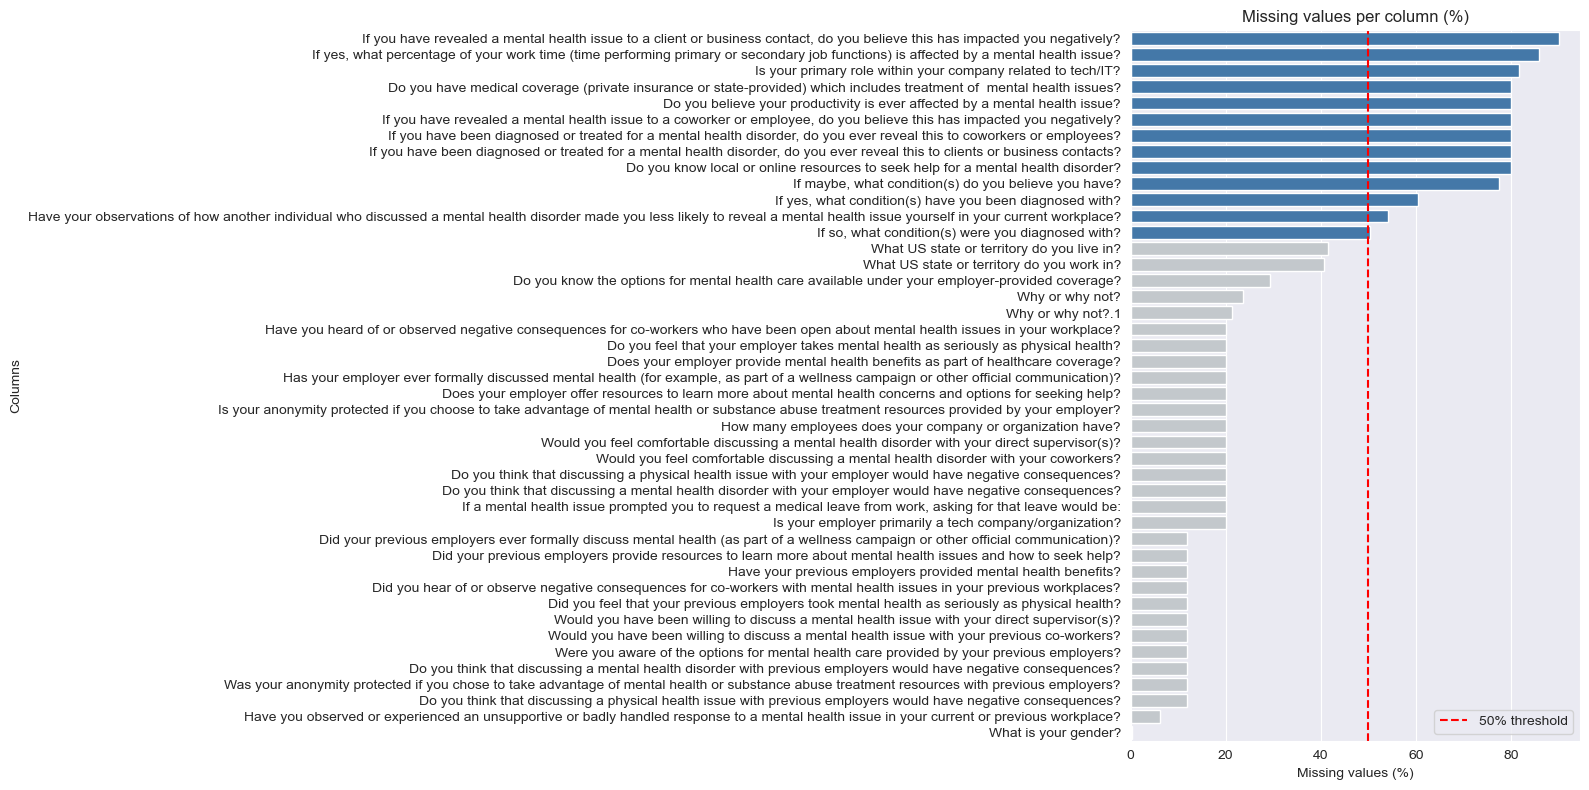

In [14]:
plt.figure(figsize=(16, 8)), 
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette=cols)
plt.xlabel('Missing values (%)')
plt.ylabel('Columns')
plt.title('Missing values per column (%)')
plt.axvline(x=50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In the chart, there are 13 columns with the percentage of missing values above 50%, with the majority exceeding 80% of the missing values. There is one column, slightly exceeding the 50% threshold - 'If so, what condition(s) were you diagnosed with?'. This column is worth keeping, as it provides an insight of the metal health state of the respondents. 

Further, the age distribution was plotted. As mentioned before, there were a few outliers. To realistically represent the working number of people, two bounds were created at 18 and 75 years old. This threshold was used in the further analysis as well. 

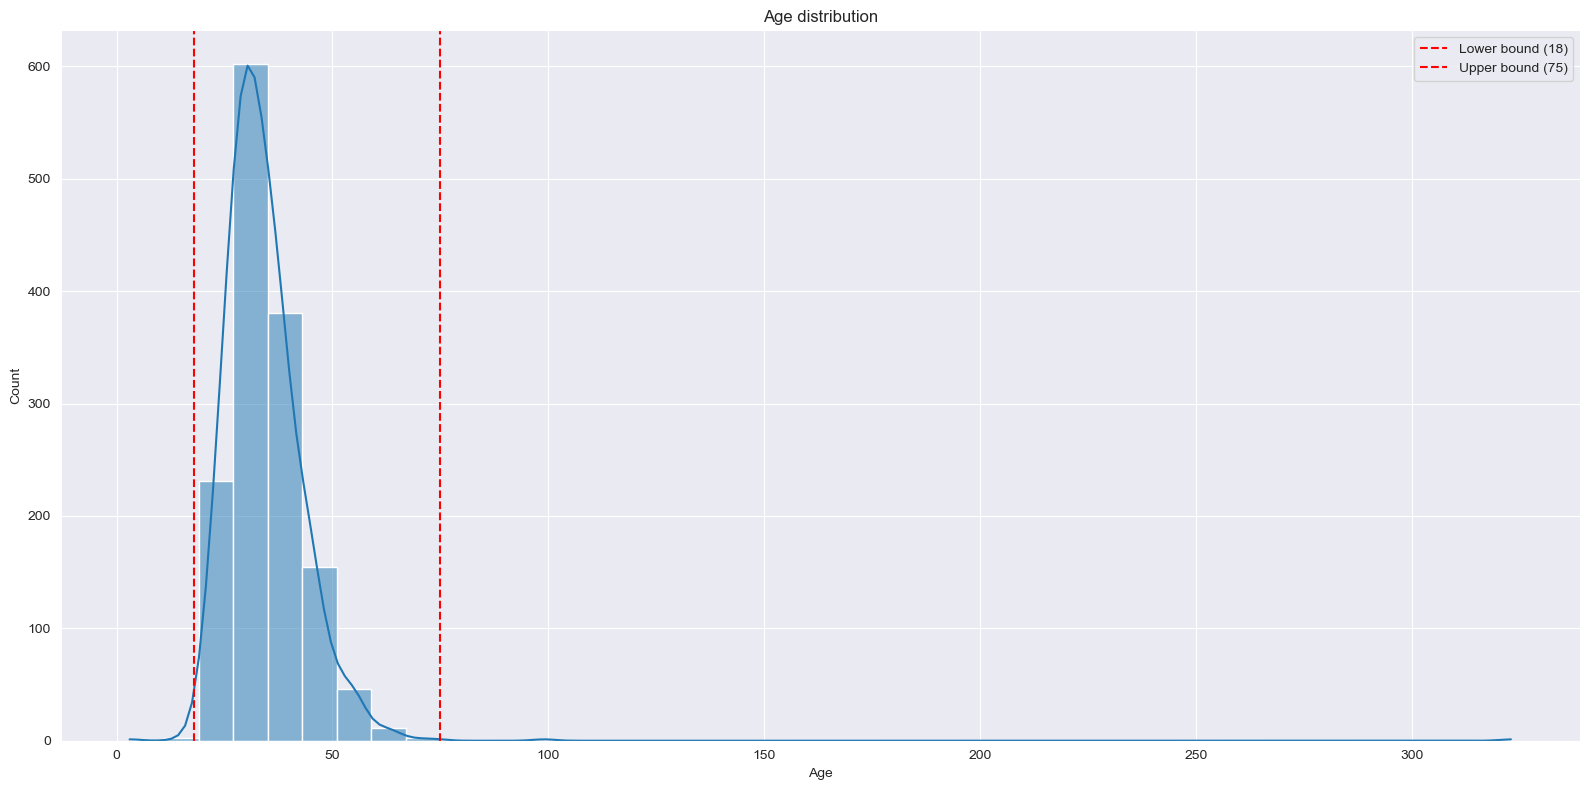

In [15]:
plt.figure(figsize=(16, 8))
sns.histplot(mh_df['What is your age?'].dropna(), bins=40, kde=True) # 40 becuase its around the √1433 
plt.title('Age distribution')
plt.xlabel('Age')
plt.axvline(x=18, color='red', linestyle='--', label='Lower bound (18)')
plt.axvline(x=75, color='red', linestyle='--', label='Upper bound (75)')
plt.legend()
plt.tight_layout()
plt.show()

The distribution of the age is within the given threshold, with few outliers. 

In addition, the plot with the top ten countries of respondents' residency was created.

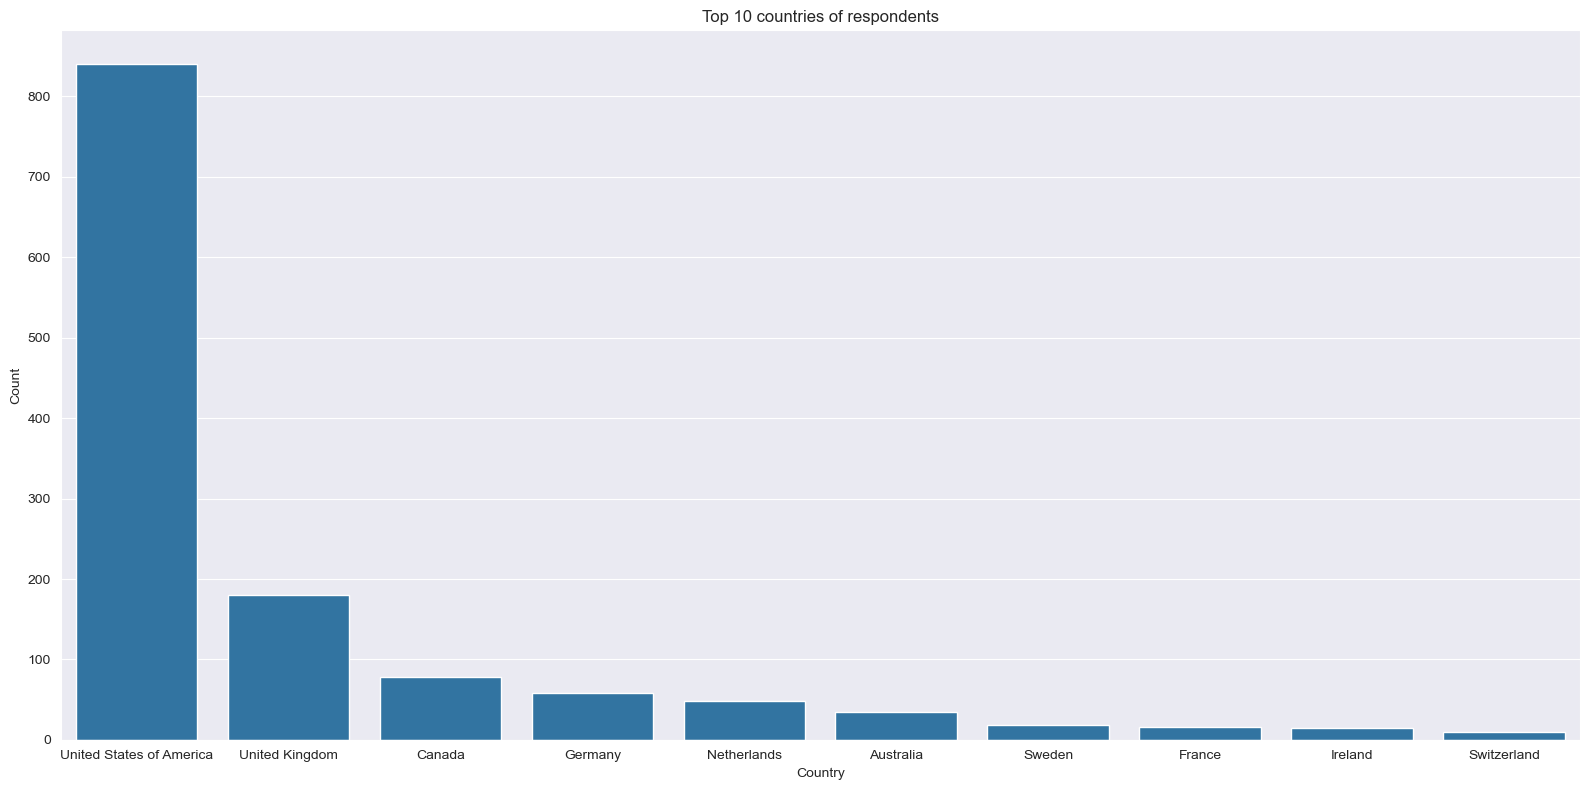

In [16]:
top_ten_countries = mh_df['What country do you live in?'].value_counts().head(10)

plt.figure(figsize=(16, 8))
sns.barplot(x=top_ten_countries.index, y=top_ten_countries.values)
plt.title('Top 10 countries of respondents')
plt.xlabel('Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [17]:
top_ten_countries

What country do you live in?
United States of America    840
United Kingdom              180
Canada                       78
Germany                      58
Netherlands                  48
Australia                    35
Sweden                       19
France                       16
Ireland                      15
Switzerland                  10
Name: count, dtype: int64

The plot indicates that the dataset is clearly dominated by the USA. Other countries on top of this list are: UK, Canada, Germany and Netherlands. 

Moreover, the gender column was analysed. As previously mentioned, there are 70 unique genders provided as values in the column. For simplicity, only top 20 were plotted. 

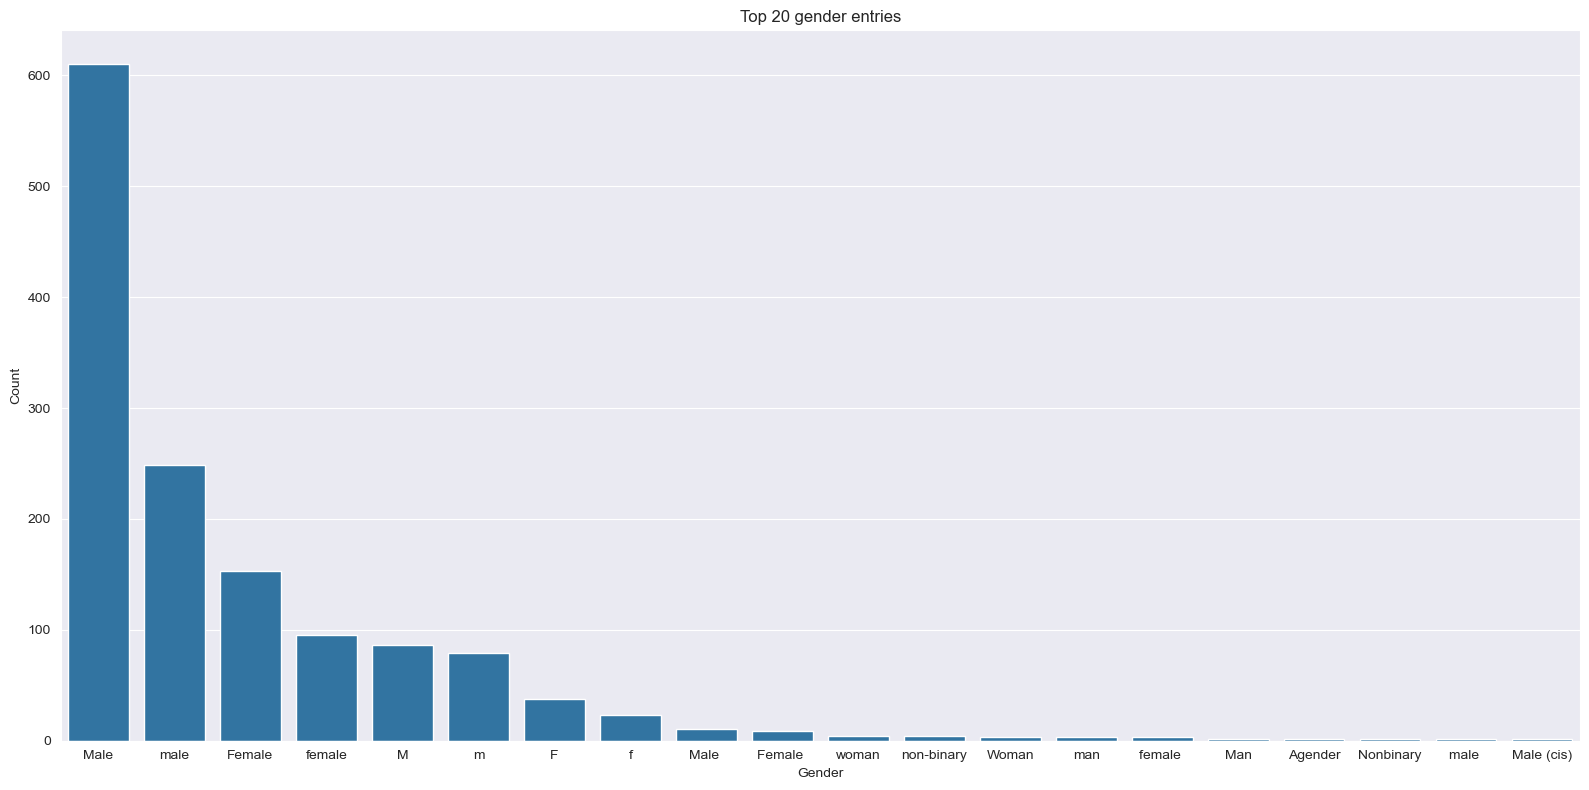

In [18]:
top_twenty_gender = mh_df['What is your gender?'].value_counts().head(20)

plt.figure(figsize=(16, 8))
sns.barplot(x=top_twenty_gender.index, y=top_twenty_gender.values)
plt.title('Top 20 gender entries')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [19]:
top_twenty_gender

What is your gender?
Male          610
male          249
Female        153
female         95
M              86
m              79
F              38
f              23
Male           11
Female          9
woman           4
non-binary      4
Woman           3
man             3
female          3
Man             2
Agender         2
Nonbinary       2
male            2
Male (cis)      2
Name: count, dtype: int64

It can be noticed that the dataset is strongly male dominated. Moreover, there are many entries representing the same gender, such as 'Female', 'female' and 'F'.

The column with answers regarding mental helth benefits was plotted as the next one. 

In [20]:
health_benefits_answers = mh_df['Does your employer provide mental health benefits as part of healthcare coverage?'].value_counts() 

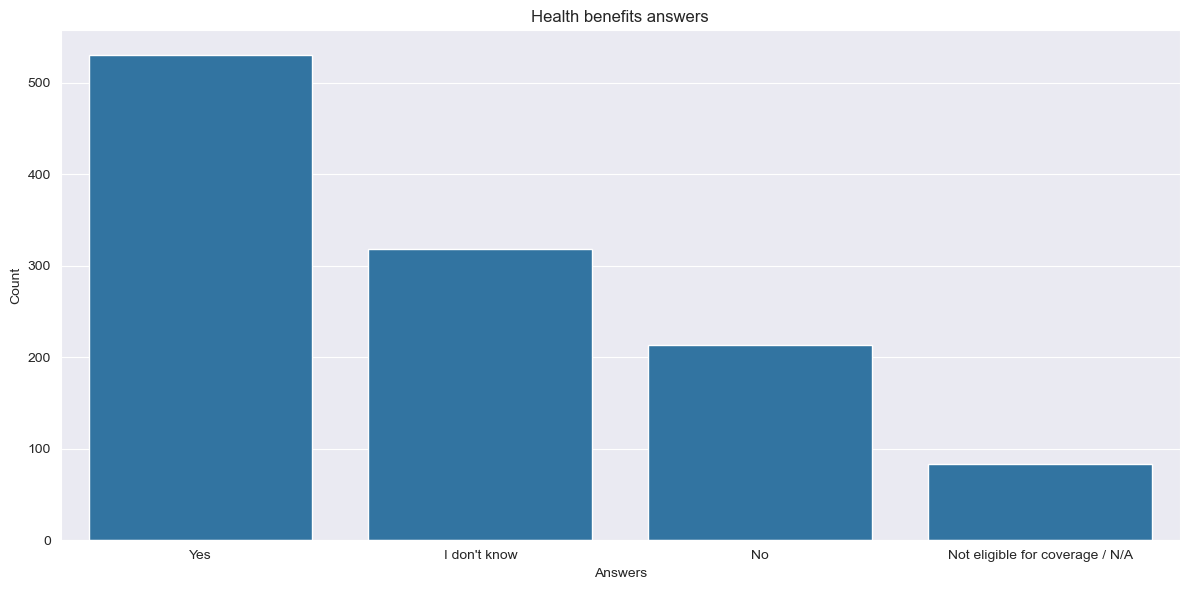

In [21]:
plt.figure(figsize=(12, 6))
sns.countplot(data=mh_df, x=mh_df['Does your employer provide mental health benefits as part of healthcare coverage?'], 
              order=mh_df['Does your employer provide mental health benefits as part of healthcare coverage?'].value_counts().index)
plt.title('Health benefits answers')
plt.xlabel('Answers')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The plot reveals that the majority of the respodents is eligible for mental health coverage. Over 300 people is not sure whether they become the coverage, over 200 does not become mental health coverage in their healthcare coverage, and less than 100 is not eligible for the coverage.

Following, the presence of the mental health disorders across respondents was plotted. 

In [22]:
disorder_answers = mh_df['Do you currently have a mental health disorder?'].value_counts()
disorder_answers

Do you currently have a mental health disorder?
Yes      575
No       531
Maybe    327
Name: count, dtype: int64

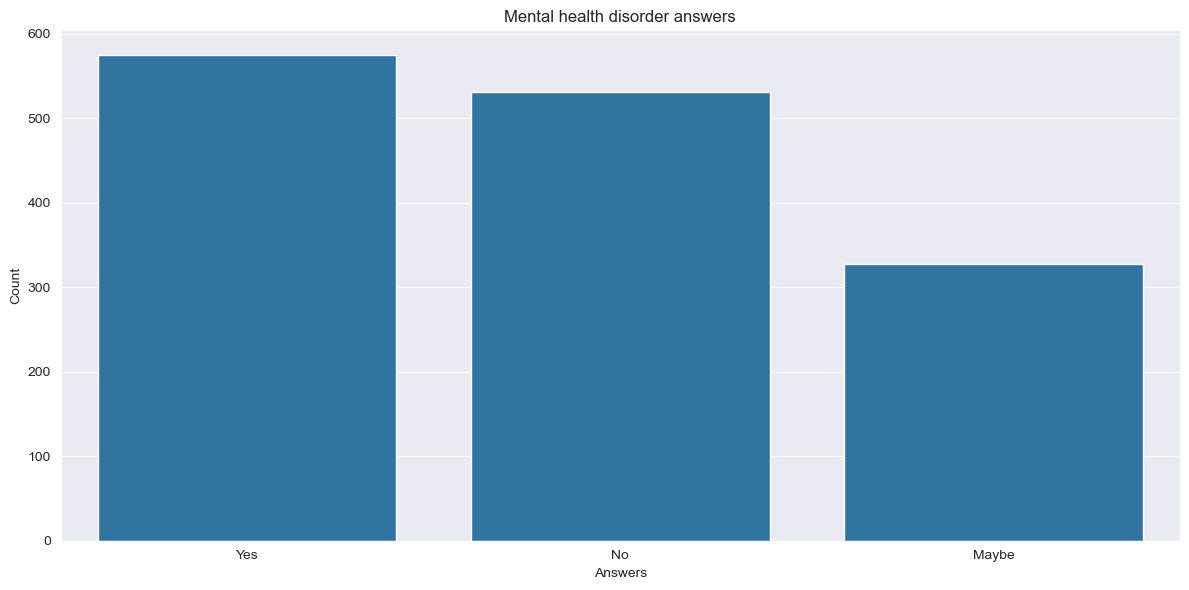

In [23]:
plt.figure(figsize=(12, 6))
sns.countplot(data=mh_df, x=mh_df['Do you currently have a mental health disorder?'], 
              order=mh_df['Do you currently have a mental health disorder?'].value_counts().index)
plt.title('Mental health disorder answers')
plt.xlabel('Answers')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

This indicates that the respondents are affected by mental health problems. 

Another important column plotted was the one with the answers regarding seeking treatment for a mental health issue. 

In [24]:
treatment_answers = mh_df['Have you ever sought treatment for a mental health issue from a mental health professional?'].value_counts()
treatment_answers

Have you ever sought treatment for a mental health issue from a mental health professional?
1    839
0    594
Name: count, dtype: int64

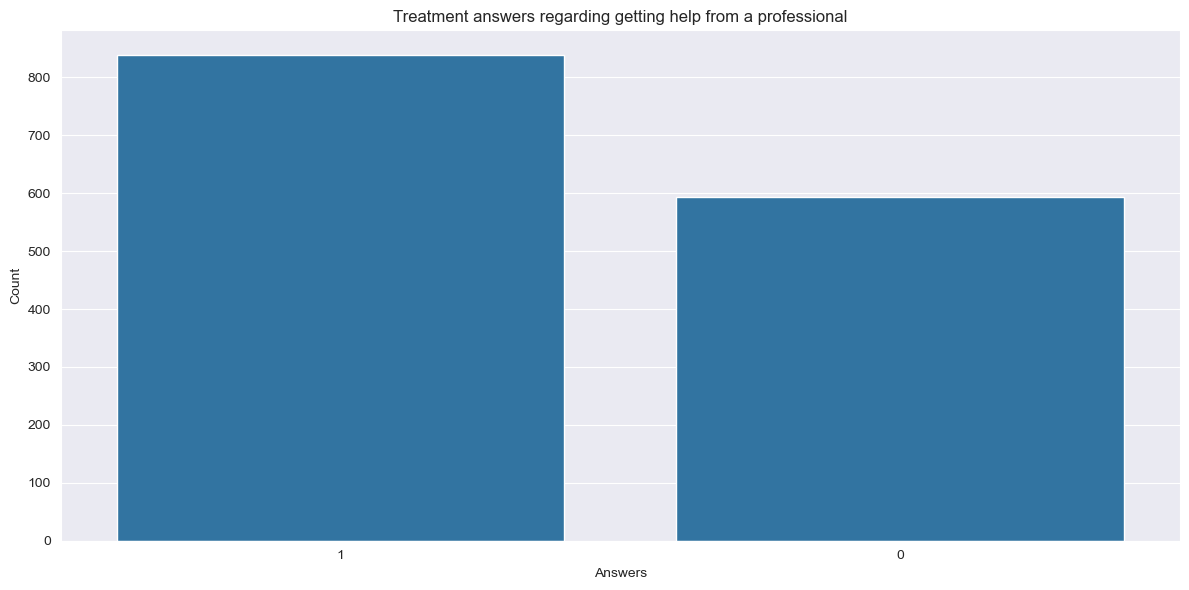

In [25]:
plt.figure(figsize=(12, 6))
sns.countplot(data=mh_df, x=mh_df['Have you ever sought treatment for a mental health issue from a mental health professional?'], 
              order=mh_df['Have you ever sought treatment for a mental health issue from a mental health professional?'].value_counts().index)
plt.title('Treatment answers regarding getting help from a professional')
plt.xlabel('Answers')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The majority of people responded that they have sought mental health treatment from proffesional. 

As for another column to plot the one reagrding whether the employer takes mental health as seriously as physical health was chosen. 

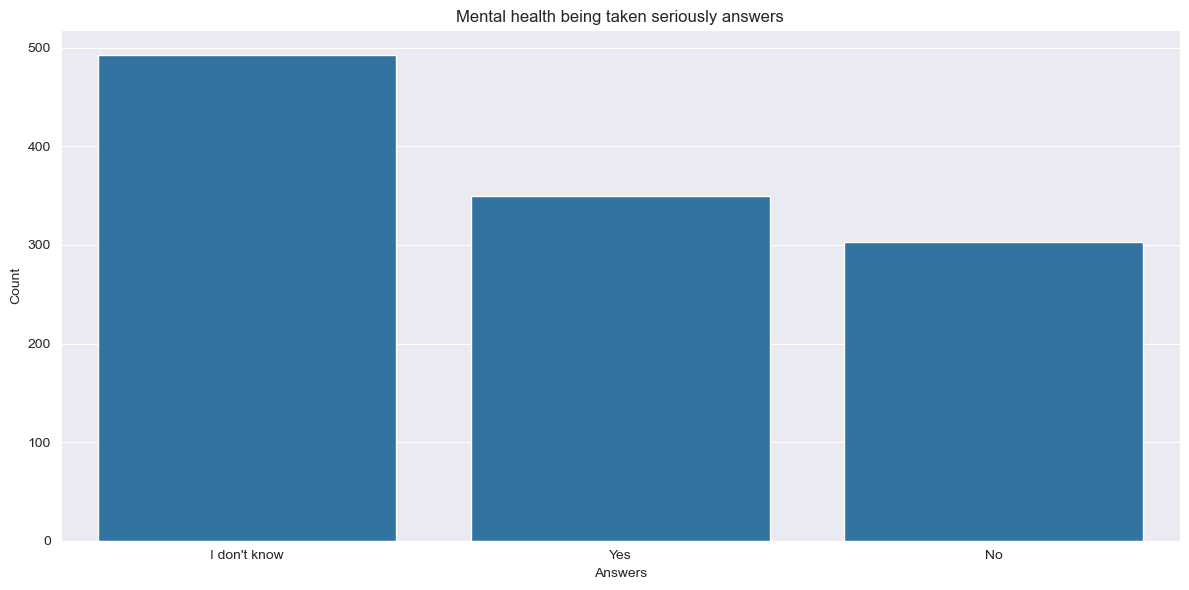

In [26]:
plt.figure(figsize=(12, 6))

sns.countplot(data=mh_df, x=mh_df['Do you feel that your employer takes mental health as seriously as physical health?'],
              order=mh_df['Do you feel that your employer takes mental health as seriously as physical health?'].value_counts().index)
plt.title('Mental health being taken seriously answers')
plt.xlabel('Answers')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [27]:
serious_answers = mh_df['Do you feel that your employer takes mental health as seriously as physical health?'].value_counts()
serious_answers


Do you feel that your employer takes mental health as seriously as physical health?
I don't know    493
Yes             350
No              303
Name: count, dtype: int64

The majority of the people said that they are not sure whether mental health is treated in the same way as the physical health is. 

Additionaly, the plot with the presence of mental health disorders across different age groups was plotted. 

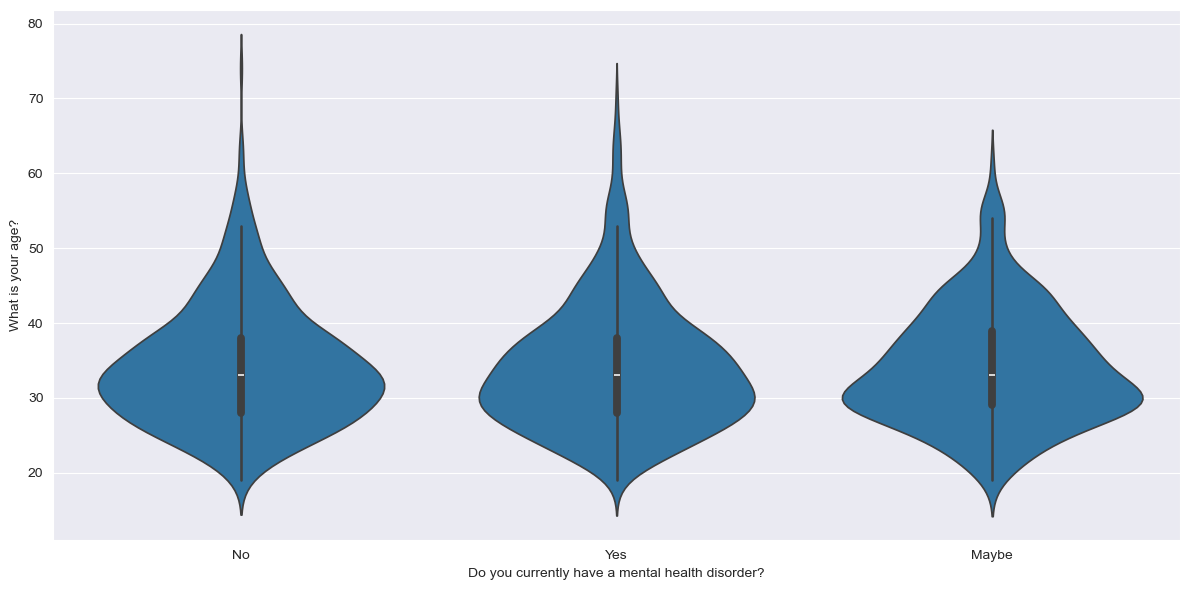

In [28]:
age = mh_df[(mh_df['What is your age?'] >= 18) & (mh_df['What is your age?'] <= 75)]
plt.figure(figsize=(12, 6)) 
sns.violinplot(data=age, x='Do you currently have a mental health disorder?', y='What is your age?')
plt.tight_layout()
plt.show()


As it can be noticed above, the disrtibution of the answers is similar, with mental health disorders being slighly more present in the slighlty younger groups of respondents. 

Also, the impact of the job type (online or offline) on mental health was explored.

In [29]:
colours = {'Yes': '#F01313', 'Maybe': '#C0C4D1', 'No':'#47BA54'}

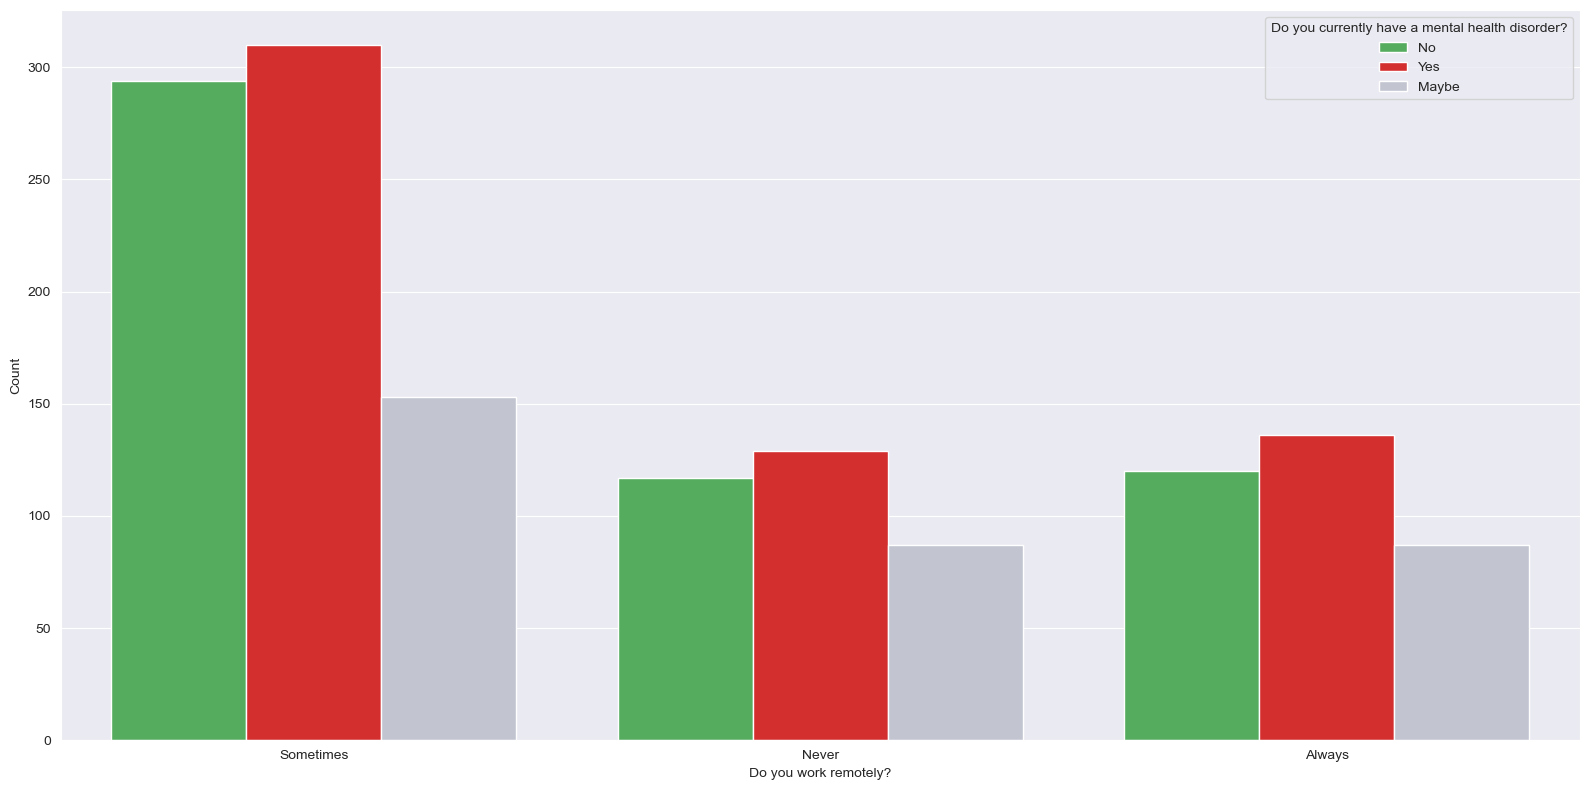

In [30]:
plt.figure(figsize=(16, 8)) 
sns.countplot(data=mh_df, x='Do you work remotely?', hue='Do you currently have a mental health disorder?', palette=colours)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

To my surprise, people having a hybrid work style, have the most number of mental health issues. Moreover, across all work types, mental health issues are dominating the other answers, which means that it is a serious problem regardless of work type. 

Further, the presence of mental health issues across different countries was analysed. 

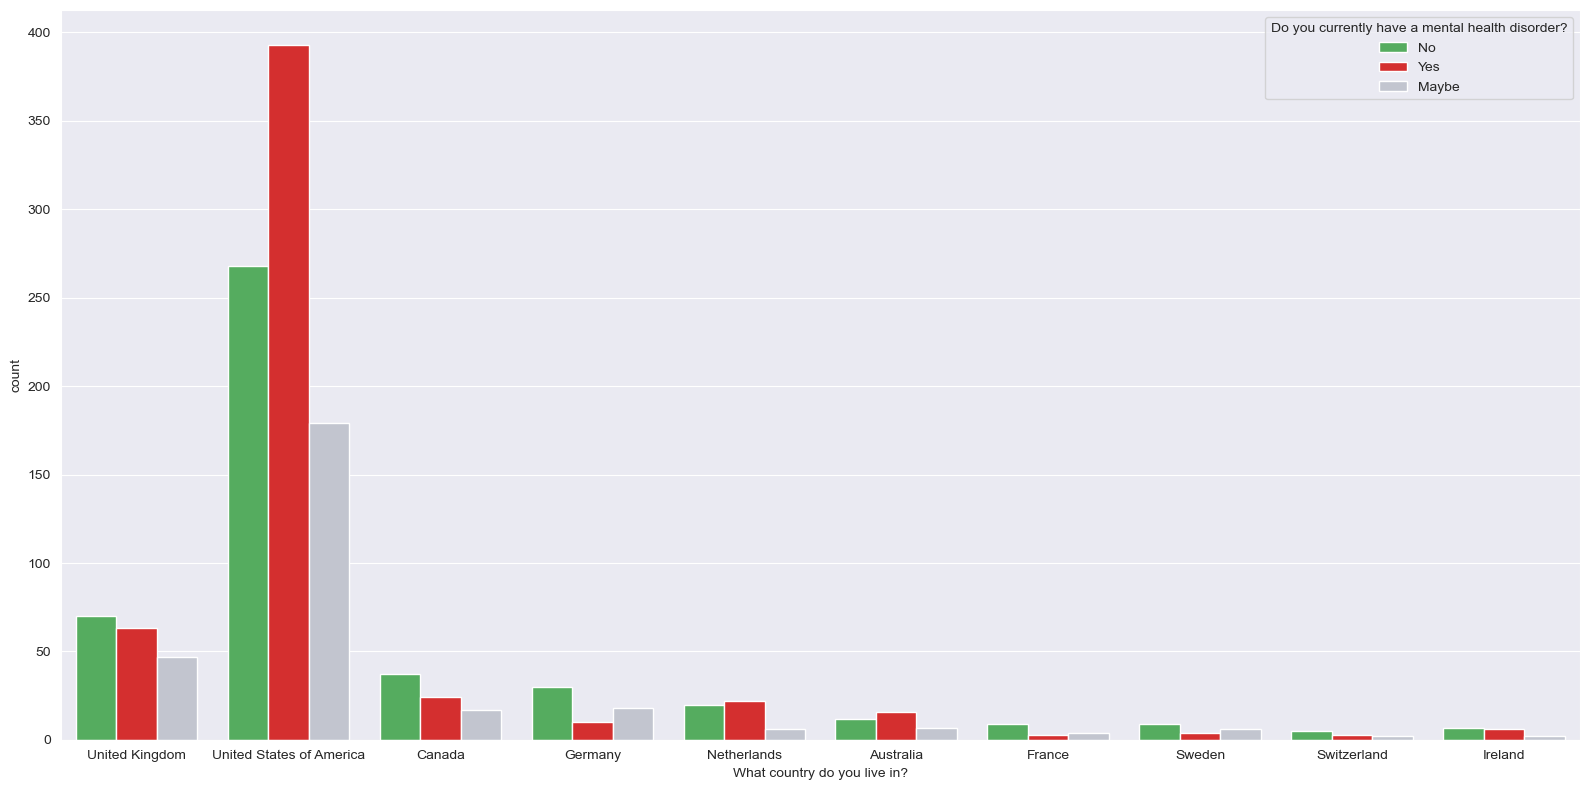

In [31]:
top_ten_countries = mh_df['What country do you live in?'].value_counts().head(10).index
filtered = mh_df[mh_df['What country do you live in?'].isin(top_ten_countries)]
plt.figure(figsize=(16,8))
sns.countplot(data=filtered, x='What country do you live in?', hue='Do you currently have a mental health disorder?', palette=colours)
plt.tight_layout()
plt.show()


The plot reveals that in the USA people struggle the most with mental health issues. The number is pretty high, which should not be surprising - the dataset is USA dominated. Nevertheless, across top ten countries of respondents, only USA, Netherlands and Austraila have more people struggling with mental health than not, with USA having way more people affected by that, compared to other countries. 

# 3. Data Preprocessing and Feature Engineering 
In this section, the following tasks were conducted:
- dropping unneccessary columns 
- handling outliers in the age column 
- cleaning the gender column and creating 5 new categories
- cleaning the country of residency column
- cleaning the job position column and extracting job positions
- dealing with the missing values in the remaining columns 
- cleaning the mental health disease column and extracting them
- handling the nominal and ordinal columns 
- extracting features from free text columns 

First, an overview dataframe of the columns with 50% of the missing values was created. Also, the number of the unique values per column was checked and a sample of values were extracted to get a proper understaning about the columns. This process was necessary to reach the decision about dropping the columns. 

In [32]:
high_missing = overview_df[overview_df['missing percentage'] > 50].sort_values(by='missing percentage', ascending=False).index.tolist()
for col in high_missing:
    print(f"\n{col}")
    print(f"Missing: {overview_df.loc[col, 'missing percentage']}%")
    print(f"Unique values: {overview_df.loc[col, 'unique values']}")
    print(f"Sample: {mh_df[col].dropna().unique()[:5]}")


If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?
Missing: 90.0%
Unique values: 3
Sample: ["I'm not sure" 'Yes' 'No']

If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?
Missing: 85.8%
Unique values: 4
Sample: ['1-25%' '76-100%' '26-50%' '51-75%']

Is your primary role within your company related to tech/IT?
Missing: 81.6%
Unique values: 2
Sample: [1. 0.]

Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?
Missing: 80.0%
Unique values: 2
Sample: [1. 0.]

Do you know local or online resources to seek help for a mental health disorder?
Missing: 80.0%
Unique values: 3
Sample: ['Yes, I know several' 'I know some' "No, I don't know any"]

If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?
Missing:

Based on the findings, the 'If so, what condition(s) were you diagnosed with?' column was chosen as the one to keep in the analysis. The missing values may come from not answearing 'Yes' in the previous question, as this column name is conditional, starting with 'If so'. This column holds important and valuable insights about the mental health of the respondents, which may be crucial to the analysis. 

The rest of the columns were decided to be dropped, since the ratio of missing values is too high. Keeping them or filling up the missing values with the mode would introduce bias in the data. 

Here a proper justification of why each of the following column was dropped is presented:
- If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively? - too many missing values 
- If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue? - same as above 
- Is your primary role within your company related to tech/IT? -//- 
- Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues? -//-
- Do you know local or online resources to seek help for a mental health disorder? -//-
- If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts? -//-
- If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees? -//-
- If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively? -//-
- Do you believe your productivity is ever affected by a mental health issue? -//-
- If maybe, what condition(s) do you believe you have? -//-
- If yes, what condition(s) have you been diagnosed with? -//-
- Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace? -//-
- What US state or territory do you live in? - this column was be dropped as it refers only to the USA. As the dataset is already USA dominated, this column is redundant
- What US state or territory do you work in? - same as above 
- What country do you work in?' - this column was dropped because the country where respondents live may have a bigger impact on their mental health, as well a bigger value for this analysis

In [33]:
mh_df.drop(['If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?', 
            'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?',
            'Is your primary role within your company related to tech/IT?',
            'Do you have medical coverage (private insurance or state-provided) which includes treatment of \xa0mental health issues?',
            'Do you know local or online resources to seek help for a mental health disorder?',
            'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?',
            'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?',
            'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?',
            'Do you believe your productivity is ever affected by a mental health issue?',
            'If maybe, what condition(s) do you believe you have?',
            'If yes, what condition(s) have you been diagnosed with?',
            'Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?',
            'What US state or territory do you live in?',
            'What US state or territory do you work in?',
            'What country do you work in?'], 
            axis='columns', inplace=True)


In [34]:
mh_df.columns

Index(['Are you self-employed?',
       'How many employees does your company or organization have?',
       'Is your employer primarily a tech company/organization?',
       'Does your employer provide mental health benefits as part of healthcare coverage?',
       'Do you know the options for mental health care available under your employer-provided coverage?',
       'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?',
       'Does your employer offer resources to learn more about mental health concerns and options for seeking help?',
       'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?',
       'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:',
       'Do you think that discussing a mental health disorder with your employer would have negative

In [35]:
mh_df.shape

(1433, 48)

15 columns were successfully dropped, changing the number of features from 63 to 48. 

In the next step, the age column was handled. To realisticaly present the working age, the working age from 18 to 75 was selected as the threshold range. 

In [36]:
ages_to_drop = mh_df[(mh_df['What is your age?'] < 18) | (mh_df['What is your age?'] > 75)].index
mh_df.drop(ages_to_drop, inplace=True)

In [37]:
mh_df.shape

(1428, 48)

It can be clearly seen that the outlier were dropped successfully. 

Following, the gender column was handled. To get a glimps of the genders selected by respondents, the top 25 of the most frequent entries and bottom 25 least frequent entries was obtained.

In [38]:
mh_df['What is your gender?'].value_counts().head(25)

What is your gender?
Male                                                                                                                                                             608
male                                                                                                                                                             247
Female                                                                                                                                                           153
female                                                                                                                                                            95
M                                                                                                                                                                 86
m                                                                                                                                                         

In [39]:
mh_df['What is your gender?'].value_counts().tail(25)

What is your gender?
genderqueer woman               1
I identify as female.           1
Bigender                        1
Female assigned at birth        1
fm                              1
Cis female                      1
Transitioned, M2F               1
Genderfluid (born female)       1
Other/Transfeminine             1
Female or Multi-Gender Femme    1
female/woman                    1
Cis male                        1
Male.                           1
Androgynous                     1
male 9:1 female, roughly        1
nb masculine                    1
Cisgender Female                1
Sex is male                     1
genderqueer                     1
cis male                        1
Human                           1
Genderfluid                     1
Enby                            1
Malr                            1
MALE                            1
Name: count, dtype: int64

In [40]:
mh_df['What is your gender?'].nunique()

69

There are 69 unique gender entries in total. 
It can also be noticed that most of the top 25 gender entries are male, female, nonbinary, women, men, f, m, which sometimes refer to the same gender, but are written differently. To handle this cases 5 different gender categories were created: 
- female
- male 
- nonbinary
- other
- unknow - in case of the missing value 

Further, the mapping was applied to this column to replace repeating entries with the new, unified categories. 

# creating a clean list with all the entries from the column !!! potentailly remove? 
genders = mh_df['What is your gender?']
updated_genders = []
for gender in genders:
    updated_genders.append(str(gender).lower().strip().split(' '))
    
print(updated_genders)


In [41]:
# creating a function that will correct the entries to the new ones 
def correct_genders(gender):
    '''
    This is a function that converts similar gender entries into unified categories.
    It goes though the column and for each entry specified below, it assignes new gender category: unknown, female, male, nonbinary or other. 
    
    '''
    if pd.isna(gender):
        return 'unknown'
            
    gen = str(gender).lower().strip().split()

    if ('f' in gen or 'female' in gen or 'woman' in gen or 'women' in gen or 'cis female' in gen):
        return 'female'
    elif ('m' in gen or 'male' in gen or 'man' in gen or 'men' in gen or 'dude' in gen or 'cis man' in gen or 'cis male' in gen):
        return 'male'
    elif ('non' in gen or 'queer' in gen or 'fluid' in gen or 'agender' in gen or 'enby' in gen or 'androgyn' in gen or 'nb' in gen or 'non-binary' in gen):
        return 'nonbinary'
    else:
        return 'other'    

In [42]:
# creating new gender column 
mh_df['Gender'] = mh_df['What is your gender?'].apply(correct_genders)

In [43]:
mh_df['Gender'].value_counts()

Gender
male         1050
female        336
other          29
nonbinary      10
unknown         3
Name: count, dtype: int64

The mapping was successfuly applied, creating 5 different gender categories, which better represent the data. The old gender column was dropped.

In [44]:
mh_df.drop(columns=['What is your gender?'], inplace=True)


Additionally, the country of residency column was handled. Top 8 most frequent occuring countries were chosen to be used in the analysis, and the rest of them to be replaced with 'Other' category for simplicity purposes. 

In [45]:
mh_df['What country do you live in?'].value_counts()


What country do you live in?
United States of America    838
United Kingdom              180
Canada                       76
Germany                      58
Netherlands                  48
Australia                    35
Sweden                       19
France                       16
Ireland                      15
Switzerland                  10
New Zealand                   9
India                         9
Brazil                        9
Russia                        9
Bulgaria                      7
Finland                       7
Denmark                       7
Italy                         5
Belgium                       5
South Africa                  4
Romania                       4
Spain                         4
Poland                        4
Austria                       4
Norway                        3
Pakistan                      3
Chile                         3
Czech Republic                3
Japan                         2
Israel                        2
Other      

In [46]:
top_eight_countries = mh_df['What country do you live in?'].value_counts().head(8).index.to_list()

In [47]:
def correct_countries(country):
    '''
    This function checks whether a country is in a list of top eight countries of the dataset and keeps it in such case. 
    Otherwise, it replaces the country with new category 'Other'.
    '''
    if country in top_eight_countries:
       return country 
    else:
        return 'Other'

In [48]:
# creating a new column
mh_df['Countries of residency'] = mh_df['What country do you live in?'].apply(correct_countries)

In [49]:
# checking out the result 
mh_df['Countries of residency'].value_counts()

Countries of residency
United States of America    838
United Kingdom              180
Other                       158
Canada                       76
Germany                      58
Netherlands                  48
Australia                    35
Sweden                       19
France                       16
Name: count, dtype: int64

The mapping was successfully applied. The old column was removed from the dataset. 

In [50]:
mh_df.drop(columns=['What country do you live in?'], inplace=True)

Further, the column representing the respondents job position was handled. 

First, top 20 most frequently occuring job positions were obtained, as well as top 20 bottom ones to get an impression of the answers. 

In [51]:
mh_df['Which of the following best describes your work position?'].value_counts().head(20)


Which of the following best describes your work position?
Back-end Developer                                             261
Front-end Developer                                            124
Other                                                          111
Supervisor/Team Lead                                            67
Back-end Developer|Front-end Developer                          61
DevOps/SysAdmin                                                 54
One-person shop                                                 50
Executive Leadership                                            46
Front-end Developer|Back-end Developer                          40
Support                                                         34
Dev Evangelist/Advocate                                         28
Designer                                                        28
Supervisor/Team Lead|Back-end Developer                         19
Front-end Developer|Designer                                    18
DevO

In [52]:
mh_df['Which of the following best describes your work position?'].value_counts().tail(20)


Which of the following best describes your work position?
Other|One-person shop|Back-end Developer|Sales|Support|DevOps/SysAdmin|Dev Evangelist/Advocate|Supervisor/Team Lead           1
HR|Dev Evangelist/Advocate|Sales                                                                                              1
One-person shop|Back-end Developer|Other                                                                                      1
Other|Executive Leadership|Supervisor/Team Lead|Dev Evangelist/Advocate|DevOps/SysAdmin|Back-end Developer|One-person shop    1
DevOps/SysAdmin|Front-end Developer|Back-end Developer                                                                        1
Supervisor/Team Lead|DevOps/SysAdmin|Support|Back-end Developer|Front-end Developer                                           1
One-person shop|Back-end Developer|DevOps/SysAdmin|Dev Evangelist/Advocate|Other                                              1
Other|Dev Evangelist/Advocate|One-person shop 

As it can be seen, some of the answers include many positions. The positions were extracted from these entries, and summed up in the end. The method get_dummies() was used to perform the extraction with the separator sep='|' chosen as the dividor. 

In [53]:
position_dummies = mh_df['Which of the following best describes your work position?'].str.get_dummies(sep='|')

In [54]:
# checking the output 
position_dummies

,Back-end Developer,Designer,Dev Evangelist/Advocate,DevOps/SysAdmin,Executive Leadership,Front-end Developer,HR,One-person shop,Other,Sales,Supervisor/Team Lead,Support
0,1,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0
4,1,0,1,1,1,1,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1428,0,0,0,0,0,0,0,0,1,0,0,0
1429,0,0,0,0,0,0,0,0,0,0,0,1
1430,1,0,0,0,0,0,0,0,0,0,0,0
1431,0,0,0,1,0,0,0,0,0,0,0,0


By looking at the table above, it is clear that there are 12 different positions across the respondents. For each column, 1 is assigned if a person has a certain position. This also handles cases of people having multiple positions. 

Also, the total number of people having a certain position was calculated.

In [55]:
count_positions = position_dummies.sum()

In [56]:
count_positions

Back-end Developer         735
Designer                   135
Dev Evangelist/Advocate     99
DevOps/SysAdmin            282
Executive Leadership       101
Front-end Developer        501
HR                          12
One-person shop            161
Other                      186
Sales                       31
Supervisor/Team Lead       276
Support                    168
dtype: int64

In this case, all positions were kept. A restriction approach was considered to only include positions with more than 14 entries (10% of the dataset) and combining the rest to the other category 'Other positon'. However, the only column that was not included was the HR column, which in this case, would be redundant to not include it, and then transform it to other position. This approach could be used with more positions available. 

In [57]:
# combining the position columns with the original dataset
mh_df = pd.concat([mh_df, position_dummies], axis=1)


In [58]:
mh_df.drop('Which of the following best describes your work position?', axis=1, inplace=True)

Further, to keep track of everything, especially columns with other missing values, another overview dataframe was created. 

The missing entries in the columns with the percentage of the missing values between 15% and 50% was replaced with the new category 'unknown'. Since dropping rows with the missing values could potentially introduce bias in the data, this option was selected as it preserves the information that the question was not answered, which allows the model to cluster respondents accurately. 

In [59]:
overview_df = pd.DataFrame({
    'data type': mh_df.dtypes,
    'missing values': mh_df.isnull().sum(),
    'missing percentage': (mh_df.isnull().sum() / len(mh_df) * 100).round(1),
    'unique values': mh_df.nunique()
})

In [60]:
other_missing = overview_df[(overview_df['missing percentage'] < 50) & (overview_df['missing percentage'] > 15)]
columns_to_fill = other_missing.index.tolist()

In [61]:
mh_df[columns_to_fill] = mh_df[columns_to_fill].fillna('Unknown')

In the following step, for the remaining columns with the percentage of the missing values less than 15%, the missing values were replaced with the mode of the column. 
The number of missing values is low enough to use the mode as the dominant category. 

In [62]:
# getting the columns with low percentage of missing values (less than 15%) and filling it up with the mode of the column
low_missing = overview_df[(overview_df['missing percentage'] > 0) & (overview_df['missing percentage'] <= 15)]
low_missing_cols = low_missing.index.tolist()

for col in low_missing_cols:
    mode_value = mh_df[col].mode()[0]
    mh_df[col] = mh_df[col].fillna(mode_value)

To be certain, a quick check up was run to see whether there are any columns with any missing values.

In [63]:
remaining = mh_df.isnull().sum()
remaining = remaining[remaining > 0]
print("Remaining columns with missing values:")
print(remaining)

Remaining columns with missing values:
If so, what condition(s) were you diagnosed with?    719
dtype: int64


The only column left with high number of the missing value is the one that was decided to be kept since it may have valuable insights about the mental health state of the respondents.

The mental health conditions were extracted next. The output was restricted to the top 5 most frequent ones. 

In [64]:
# checking the values in the column 
mh_df['If so, what condition(s) were you diagnosed with?']

0       Anxiety Disorder (Generalized, Social, Phobia,...
1       Anxiety Disorder (Generalized, Social, Phobia,...
2                                                     NaN
3       Anxiety Disorder (Generalized, Social, Phobia,...
4       Anxiety Disorder (Generalized, Social, Phobia,...
                              ...                        
1428                                                  NaN
1429    Psychotic Disorder (Schizophrenia, Schizoaffec...
1430    Anxiety Disorder (Generalized, Social, Phobia,...
1431    Mood Disorder (Depression, Bipolar Disorder, etc)
1432                                                  NaN
Name: If so, what condition(s) were you diagnosed with?, Length: 1428, dtype: object

The features were split based on the dividor '|' as it clearly indicates multiple conditions selection by a person. Next, the features were extracted by explode method. 

In [65]:
health_conditions = mh_df['If so, what condition(s) were you diagnosed with?'].dropna().str.split('|').explode().str.strip()
top_five_conditions = health_conditions.value_counts().head(5).index.to_list()

In [66]:
top_five_conditions

['Mood Disorder (Depression, Bipolar Disorder, etc)',
 'Anxiety Disorder (Generalized, Social, Phobia, etc)',
 'Attention Deficit Hyperactivity Disorder',
 'Post-traumatic Stress Disorder',
 'Obsessive-Compulsive Disorder']

In [67]:
# creating a column for presence of each condition of the respondents 
for condition in top_five_conditions:
    condition_name = condition.replace('(','').replace(')','')
    mh_df[condition_name] = mh_df['If so, what condition(s) were you diagnosed with?'].str.contains(condition, na=False).astype(int)


/var/folders/j2/mzg4562d1tldwwf84136fq8h0000gn/T/ipykernel_67901/3546281721.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mh_df[condition_name] = mh_df['If so, what condition(s) were you diagnosed with?'].str.contains(condition, na=False).astype(int)
/var/folders/j2/mzg4562d1tldwwf84136fq8h0000gn/T/ipykernel_67901/3546281721.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mh_df[condition_name] = mh_df['If so, what condition(s) were you diagnosed with?'].str.contains(condition, na=False).astype(int)


In [68]:
# dropping the old condition column
mh_df.drop(columns=['If so, what condition(s) were you diagnosed with?'], inplace=True)


In [69]:
# checking the data frame after the preprocessing 
mh_df

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,...,One-person shop,Other,Sales,Supervisor/Team Lead,Support,"Mood Disorder Depression, Bipolar Disorder, etc","Anxiety Disorder Generalized, Social, Phobia, etc",Attention Deficit Hyperactivity Disorder,Post-traumatic Stress Disorder,Obsessive-Compulsive Disorder
0,0,26-100,1.0,Not eligible for coverage / N/A,Unknown,No,No,I don't know,Very easy,No,...,0,0,0,0,0,0,0,0,0,0
1,0,6-25,1.0,No,Yes,Yes,Yes,Yes,Somewhat easy,No,...,0,0,0,0,0,0,0,0,0,0
2,0,6-25,1.0,No,Unknown,No,No,I don't know,Neither easy nor difficult,Maybe,...,0,0,0,0,0,0,0,0,0,0
3,1,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,...,0,0,0,1,0,0,0,0,0,0
4,0,6-25,0.0,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,...,0,0,0,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,1,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,...,0,1,0,0,0,0,0,0,0,0
1429,1,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,...,0,0,0,0,1,0,0,0,0,0
1430,0,100-500,1.0,Yes,Yes,Yes,Yes,I don't know,Somewhat difficult,Maybe,...,0,0,0,0,0,0,0,0,0,0
1431,0,100-500,0.0,I don't know,I am not sure,No,Yes,I don't know,Somewhat difficult,Maybe,...,0,0,0,0,0,0,0,0,0,0


In [70]:
# checking whether there are any values missing and the data types for further analysis 
print(f"Shape: {mh_df.shape}")
print(f"Missing values: {mh_df.isnull().sum().sum()}")
print(f"\nColumn types:")
print(mh_df.dtypes.value_counts())

Shape: (1428, 63)
Missing values: 0

Column types:
object    42
int64     21
Name: count, dtype: int64


There are no missing values anymore. All the handling of the missing values was applied successfully. 

There are still 42 columns with object data type, which must be converted into the numerical values. 
The unique values were checked for each of this object column type, and, based on the findings, the proper approach was implemented. 

To check whether the columns are nominal or ordinal, a for loop was created that outputs the values for each column. 

In [71]:
for col in mh_df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(mh_df[col].unique())


How many employees does your company or organization have?:
['26-100' '6-25' 'Unknown' 'More than 1000' '100-500' '500-1000' '1-5']

Is your employer primarily a tech company/organization?:
[1.0 'Unknown' 0.0]

Does your employer provide mental health benefits as part of healthcare coverage?:
['Not eligible for coverage / N/A' 'No' 'Unknown' 'Yes' "I don't know"]

Do you know the options for mental health care available under your employer-provided coverage?:
['Unknown' 'Yes' 'I am not sure' 'No']

Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?:
['No' 'Yes' 'Unknown' "I don't know"]

Does your employer offer resources to learn more about mental health concerns and options for seeking help?:
['No' 'Yes' 'Unknown' "I don't know"]

Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?:
["I don't know" 'Yes' 'Unkno

Some of the columns are nominal. This case was simply handled by the getdummies method. The other are ordinal. For each of the ordinal columns, a corresponding mapping was applied. 

In [72]:
mapping_employees = {'26-100': 3,
                      '6-25': 2,
                      'Unknown': 0, 
                      'More than 1000': 6,
                      '100-500': 4,
                      '500-1000': 5,
                      '1-5': 1
}

mapping_mh_issue = {'Very easy': 5,
                    'Somewhat easy': 4,
                    'Neither easy nor difficult': 3,
                    'Unknown': 0,
                    'Very difficult': 1,
                    'Somewhat difficult': 2,
                    "I don't know": 0}

mapping_issue = {'Not applicable to me': 0, # applicable for 2 columns 
                  'Rarely': 2,
                  'Sometimes': 3,
                  'Never': 1,
                  'Often': 4}

mapping_sharing = {'Somewhat open': 4,
                   'Neutral': 3 ,
                   'Not applicable to me (I do not have a mental illness)': 0,
                    'Very open': 5,
                    'Not open at all': 1,
                    'Somewhat not open': 2}

mapping_remote = {'Sometimes': 1,
                  'Never': 0,
                  'Always': 2}

mapping_previous_e = {'No, none did': 1,
                    'Yes, they all did': 3,
                    'Some did': 2,
                    "I don't know": 0}

mapping_discuss_pe = {"I don't know": 0,
                      'None did': 1,
                      'Some did': 2,
                      'Yes, they all did': 3}

mapping_resources_pe = { "I don't know": 0, 
                        'None did': 1,
                        'Some did': 2,
                        'Yes, they all did': 3}

mapping_anon = {"I don't know": 0,
                 'Yes, always': 3,
                 'Sometimes': 2,
                 'No': 1}

mapping_mh_discuss = {'Some of them': 2,
                   'None of them': 1,
                   "I don't know": 0,
                   'Yes, all of them': 3}

mapping_ph_discuss = {'None of them': 1,
                      'Some of them': 2,
                      'Yes, all of them': 3}

mapping_discuss_pcw = {'Some of my previous employers': 2,
                    'No, at none of my previous employers': 1,
                    'Yes, at all of my previous employers': 3}

mapping_discuss_sv = {'Some of my previous employers': 2,
                      "I don't know": 0,
                      'No, at none of my previous employers': 1,
                      'Yes, at all of my previous employers': 3}

mapping_serious = {"I don't know": 0,
                    'Some did': 2,
                    'None did': 1,
                    'Yes, they all did': 3}

mapping_nc = {'None of them': 1,
              'Some of them': 2,
              'Yes, all of them': 3} 

mapping_aware = {'N/A (not currently aware)': 0,
                'I was aware of some': 2,
                'Yes, I was aware of all of them': 3,
                'No, I only became aware later': 1}


And now applying the mappings to the corresponding columns. 

In [73]:
mh_df['How many employees does your company or organization have?'] = mh_df['How many employees does your company or organization have?'].map(mapping_employees)

mh_df['If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:'] = mh_df['If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:'].map(mapping_mh_issue)

mh_df['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'] = mh_df['If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?'].map(mapping_issue)

mh_df['If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?'] = mh_df['If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?'].map(mapping_issue)

mh_df['How willing would you be to share with friends and family that you have a mental illness?'] = mh_df['How willing would you be to share with friends and family that you have a mental illness?'].map(mapping_sharing)

mh_df['Do you work remotely?'] = mh_df['Do you work remotely?'].map(mapping_remote)

mh_df['Have your previous employers provided mental health benefits?'] = mh_df['Have your previous employers provided mental health benefits?'].map(mapping_previous_e)

mh_df['Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'] = mh_df['Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?'].map(mapping_discuss_pe)

mh_df['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'] = mh_df['Did your previous employers provide resources to learn more about mental health issues and how to seek help?'].map(mapping_resources_pe)

mh_df['Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'] = mh_df['Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?'].map(mapping_anon)

mh_df['Do you think that discussing a mental health disorder with previous employers would have negative consequences?'] = mh_df['Do you think that discussing a mental health disorder with previous employers would have negative consequences?'].map(mapping_mh_discuss)

mh_df['Do you think that discussing a physical health issue with previous employers would have negative consequences?'] = mh_df['Do you think that discussing a physical health issue with previous employers would have negative consequences?'].map(mapping_ph_discuss)

mh_df['Would you have been willing to discuss a mental health issue with your previous co-workers?'] = mh_df['Would you have been willing to discuss a mental health issue with your previous co-workers?'].map(mapping_discuss_pcw)

mh_df['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'] = mh_df['Would you have been willing to discuss a mental health issue with your direct supervisor(s)?'].map(mapping_discuss_sv)

mh_df['Did you feel that your previous employers took mental health as seriously as physical health?'] = mh_df['Did you feel that your previous employers took mental health as seriously as physical health?'].map(mapping_serious)

mh_df['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?'] = mh_df['Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?'].map(mapping_nc)

mh_df['Were you aware of the options for mental health care provided by your previous employers?'] = mh_df['Were you aware of the options for mental health care provided by your previous employers?'].map(mapping_aware)

mh_df['Is your employer primarily a tech company/organization?'] = (mh_df['Is your employer primarily a tech company/organization?'].replace('Unknown', 0).astype(float))

/var/folders/j2/mzg4562d1tldwwf84136fq8h0000gn/T/ipykernel_67901/531564837.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mh_df['Is your employer primarily a tech company/organization?'] = (mh_df['Is your employer primarily a tech company/organization?'].replace('Unknown', 0).astype(float))


In [74]:
# checking the results 
print(mh_df.dtypes.value_counts())
print(mh_df.isnull().sum().sum())

int64      38
object     24
float64     1
Name: count, dtype: int64
0


The mapping was successfully applied to all of the ordinal column. 

As for the next step, to extract features from the two free text columns, that are 'why or why not?' and 'why or why not.1?', a TFIDF vectorization was applied. 

In [75]:
# double check whether there are any missing values
print(mh_df['Why or why not?'].isna().sum())
print(mh_df['Why or why not?.1'].isna().sum())
print(mh_df['Why or why not?'].dropna().head(3))
print(mh_df['Why or why not?.1'].dropna().head(3))

0
0
0                                              Unknown
1    It would depend on the health issue. If there ...
2    They would provable need to know, to Judge if ...
Name: Why or why not?, dtype: object
0                                              Unknown
1    While mental health has become a more prominen...
2                                     Stigma, mainly. 
Name: Why or why not?.1, dtype: object


This step shows that there are unknown values - which were assigned before. To perform proper TFIDF, these unknown values were replaced with a whitespace. 

In [76]:
text_colmh_df1 = mh_df['Why or why not?'].replace('Unknown', '')
text_colmh_df2 = mh_df['Why or why not?.1'].replace('Unknown', '')

In [77]:
# checking how large the vocabulary actually is
vocabulary_check = TfidfVectorizer(stop_words='english', min_df=2)
vocabulary_check.fit(text_colmh_df1)
print(f"Total vocabulary size: {len(vocabulary_check.vocabulary_)}")

Total vocabulary size: 689


In [78]:
# same here
vocabulary_check2 = TfidfVectorizer(stop_words='english', min_df=2)
vocabulary_check2.fit(text_colmh_df2)
print(f"Total vocabulary size: {len(vocabulary_check2.vocabulary_)}")

Total vocabulary size: 698


Both of the vocabularies have a number of words close to 700. Based on this number, the number of max_features=100 was selected as it allows model to capture around 15% of the primary textual features. Alternative number of max_features=50 was tested but it produced poor results. 

In [79]:
# dropping old columns
mh_df = mh_df.drop(columns=['Why or why not?', 'Why or why not?.1'])

In [80]:
# creating the vectorizers for both dictionaries 
vectorizer1 = TfidfVectorizer(max_features=100, min_df=2, stop_words='english')
vectorizer2 = TfidfVectorizer(max_features=100, min_df=2, stop_words='english')

In [81]:
# creating TFIDF 
tfidf1 = vectorizer1.fit_transform(text_colmh_df1)
tfidf2 = vectorizer2.fit_transform(text_colmh_df2)

In addition, the columns representing each of the word from dictionaries were created and added to the dataset. 

In [82]:
words1 = vectorizer1.get_feature_names_out()
col_names1 = ['tfidf_why1_' + w for w in words1]

tfidf1_df = pd.DataFrame(tfidf1.toarray(), columns=col_names1, index=mh_df.index)

words2 = vectorizer2.get_feature_names_out()
col_names2 = ['tfidf_why2_' + w for w in words2]

tfidf2_df = pd.DataFrame(tfidf2.toarray(), columns=col_names2, index=mh_df.index)

After successful TFIDF vectorization, the other nominal columns were simply handeled by using the getdummies method on the whole dataset. By doing this, all of the columns were automatically encoded. 

In [83]:
mh_df = pd.get_dummies(mh_df, drop_first=False)

Moreover, the columns types must be converted from the boolean type to the int type. 

In [84]:
mh_df = mh_df.astype({col: int for col in mh_df.select_dtypes(include='bool').columns})

Finally, all of the dataframes were concatinated together. 

In [85]:
mh_df = pd.concat([mh_df, tfidf1_df, tfidf2_df], axis=1)

In [86]:
# checking the results one more time
print(mh_df.shape)
print(mh_df.dtypes.value_counts())
print(mh_df.isnull().sum().sum())

(1428, 328)
float64    201
int64      127
Name: count, dtype: int64
0


# 4. Feature selection 
Before PCA, feature selection was applied.
Moreover, to properly perform the upcoming steps, such as PCA, multidimensional scaling, and clustering, the dataset was scaled. This step ensures that the large number ranges in certain features do not influence the distance calulations disproportionally. 

In [87]:
X = mh_df.copy()
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)  
from sklearn.preprocessing import MinMaxScaler # delete


scaler = StandardScaler()
X_std= scaler.fit_transform(X_selected)
X_mm = MinMaxScaler().fit_transform(X_selected)# delete

print(f"Features before filter: {X.shape[1]}")
print(f"Features after filter: {X_selected.shape[1]}")

Features before filter: 328
Features after filter: 166


After applying feature selection, the 162 features were removed. 

# 5. Principal Component Analysis 

In this section, PCA was performed. This method was selected because of the three main reasons:
1. Since data has 166 features, clustering directly on that many features would be unreliable 
2. It removes noise and concatenates variance into smaller number of components
3. It enables visualisation of multidimensional clusters

First, the standardised dataset was fitted to PCA model, and then, the explained and cumulative variances were obtained. 

In [88]:
pca = PCA(random_state=42).fit(X_std)

var_exp = pca.explained_variance_ratio_
print(var_exp)

cum_var_exp = np.cumsum(var_exp)
print(cum_var_exp)


[1.06107385e-01 5.13897582e-02 3.88266867e-02 2.30589269e-02
 1.96491841e-02 1.86504673e-02 1.65515619e-02 1.50279098e-02
 1.47749069e-02 1.44107538e-02 1.33965892e-02 1.30467938e-02
 1.24001587e-02 1.19178290e-02 1.14061600e-02 1.09616795e-02
 1.08446928e-02 1.07533006e-02 1.05191090e-02 1.03712768e-02
 1.02379218e-02 9.93845083e-03 9.86499490e-03 9.58894093e-03
 9.48836358e-03 9.13001150e-03 9.01283659e-03 8.84314273e-03
 8.67577806e-03 8.61799770e-03 8.50466514e-03 8.42680130e-03
 8.21191431e-03 8.12637226e-03 8.00441730e-03 7.90710598e-03
 7.77623941e-03 7.65488483e-03 7.58835521e-03 7.52895520e-03
 7.39584535e-03 7.38837984e-03 7.17101193e-03 7.10590396e-03
 7.06850146e-03 6.97503328e-03 6.96146712e-03 6.83962404e-03
 6.71640664e-03 6.63114115e-03 6.55158341e-03 6.52914642e-03
 6.43670684e-03 6.34369147e-03 6.27260384e-03 6.25726368e-03
 6.16044530e-03 5.99826382e-03 5.97070363e-03 5.93982110e-03
 5.78412008e-03 5.67301882e-03 5.59141366e-03 5.56812986e-03
 5.51635946e-03 5.442875

The 'Scree Plot' was created, which should help by deciding how many components to retain. 

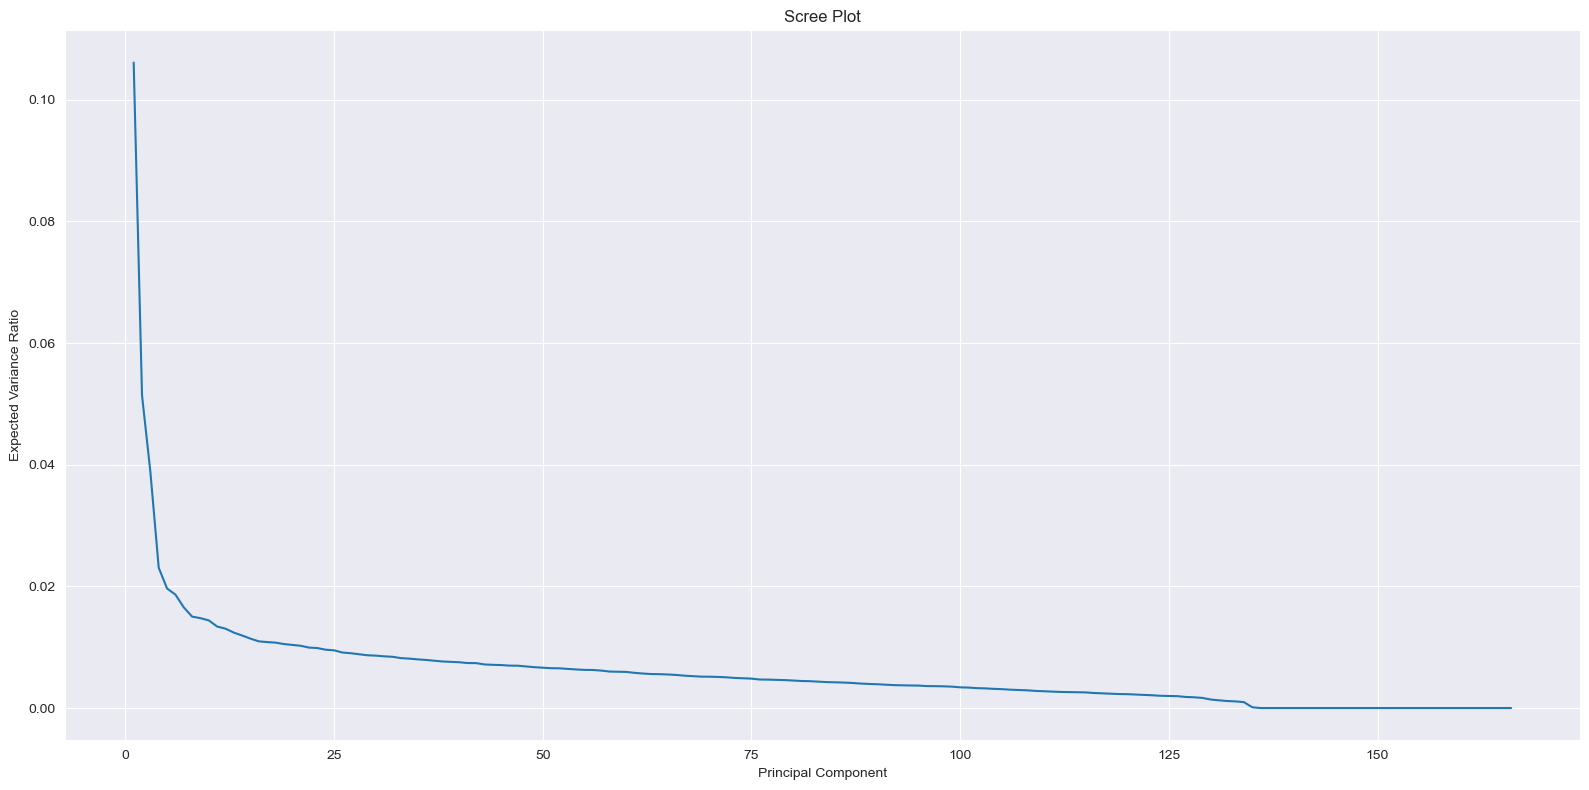

In [89]:
plt.figure(figsize=(16,8))
sns.lineplot(x=range(1, len(var_exp)+1), y=var_exp, markers='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Expected Variance Ratio')

plt.tight_layout()
plt.show()

The plot indicates that there is a rapid decrease in the expected variance ratio for the first few components, followed by a long and steady flattening. The line reflects the high dimensionality of the survey data, where there is no single dominating component. 

The number of principal components was plotted against the cumulative variance in the next step. The threshold range of 80 to 90% was added to the plot for visual purposes and to help determine the number of components needed to retain a given proportion. 

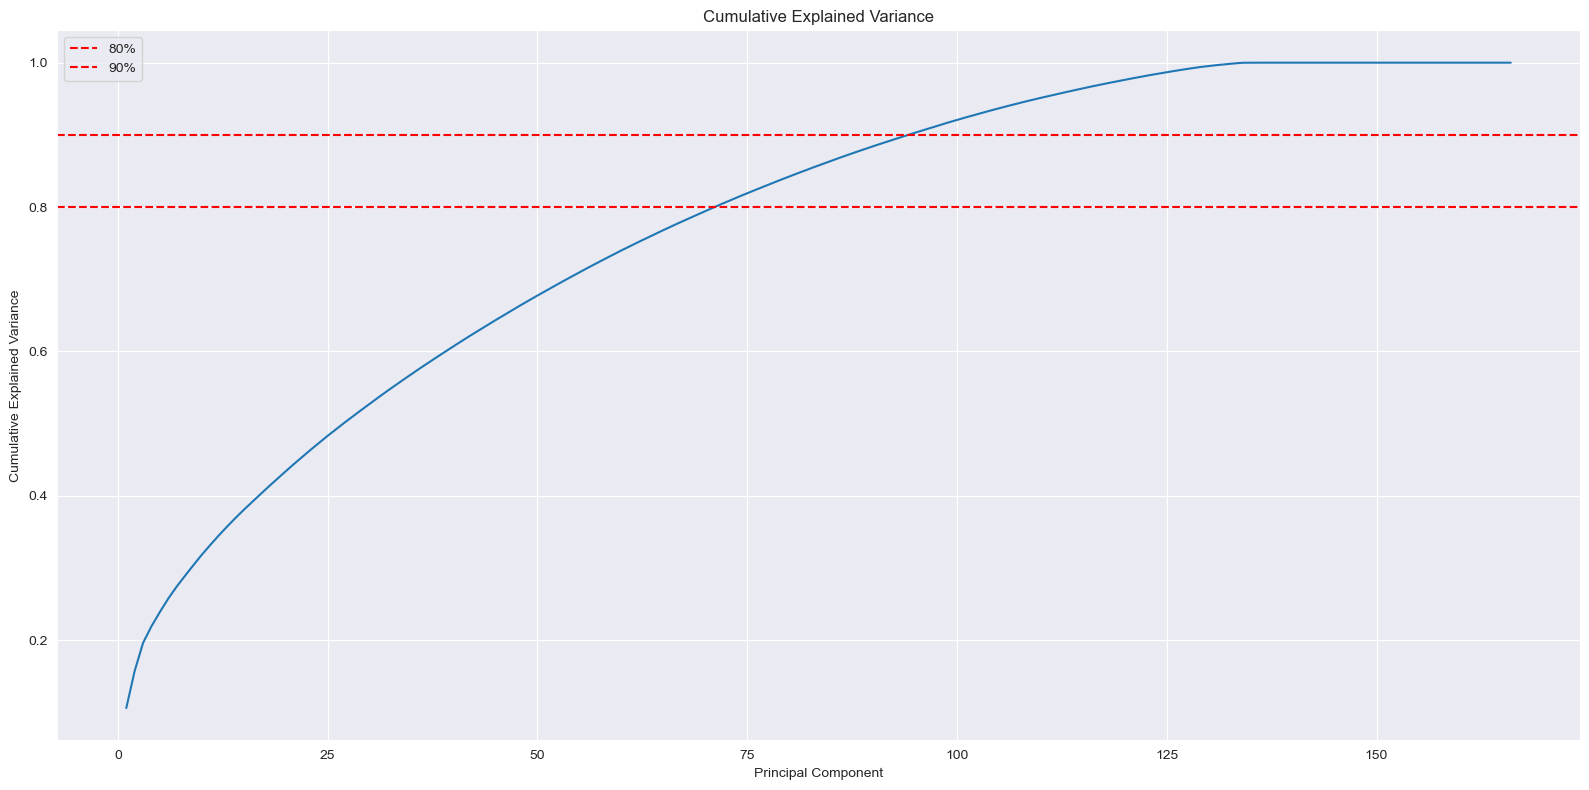

In [90]:
plt.figure(figsize=(16,8))
sns.lineplot(x=range(1, len(var_exp)+1), y=cum_var_exp, markers='o')
plt.axhline(y=0.8, color='red', linestyle='--', label='80%')
plt.axhline(y=0.9, color='red', linestyle='--', label='90%')
plt.title('Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.legend()

plt.tight_layout()
plt.show()

To get the exact values, a simple for loop was used, since the exact values cannot be easily read from the plot above. 

In [91]:
for threshold in [0.75, 0.80, 0.85, 0.90]:
    n = np.argmax(cum_var_exp >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained by {n} components")

75% variance explained by 62 components
80% variance explained by 72 components
85% variance explained by 82 components
90% variance explained by 95 components


This operation reveals that the 80% threshold reduced the number of components from 166 to 72. Even though this number is relatively high, it reflect the high dimensionality of the survey data. This is why this number was selected for PCA as it balances dimensionality reduction and also the information preservation. 

Also, another PCA models were fitted but only for clustering and visualisation purposes. 

In [92]:
pca_for_clustering = PCA(n_components=72, random_state=42)
X_pca = pca_for_clustering.fit_transform(X_std)

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_std)

print(f"Clustering matrix shape: {X_pca.shape}")
print(f"2D visualisation shape: {X_pca_2d.shape}")

Clustering matrix shape: (1428, 72)
2D visualisation shape: (1428, 2)


Further, the features were examined across their importance in each principal component. 

In [93]:
feature_names = mh_df.columns[selector.get_support()]

pc1 = pd.Series(pca_for_clustering.components_[0], index=feature_names)
pc2 = pd.Series(pca_for_clustering.components_[1], index=feature_names)

print("Top 10 features in PC1:")
print(pc1.abs().sort_values(ascending=False).head(10))

print("\nTop 10 features in PC2:")
print(pc2.abs().sort_values(ascending=False).head(10))

Top 10 features in PC1:
Do you feel that your employer takes mental health as seriously as physical health?_Unknown                                                               0.236835
Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?_Unknown               0.236835
Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?_Unknown                                                    0.236835
Would you feel comfortable discussing a mental health disorder with your coworkers?_Unknown                                                               0.236835
Do you think that discussing a physical health issue with your employer would have negative consequences?_Unknown                                         0.236835
Do you think that discussing a mental health disorder with your employer would have negative consequences?_Unknown                                        0.23683

There are two different components visible: PC1 clearly dominated by the emplyer or employment context questions, and the other one by mental health questons. This suggests that these contexts are the main axes of variance in the datasets.

In the following step, a small dataframe was created for visual purposes of PCA. 

In [94]:
X_pca_2d_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])

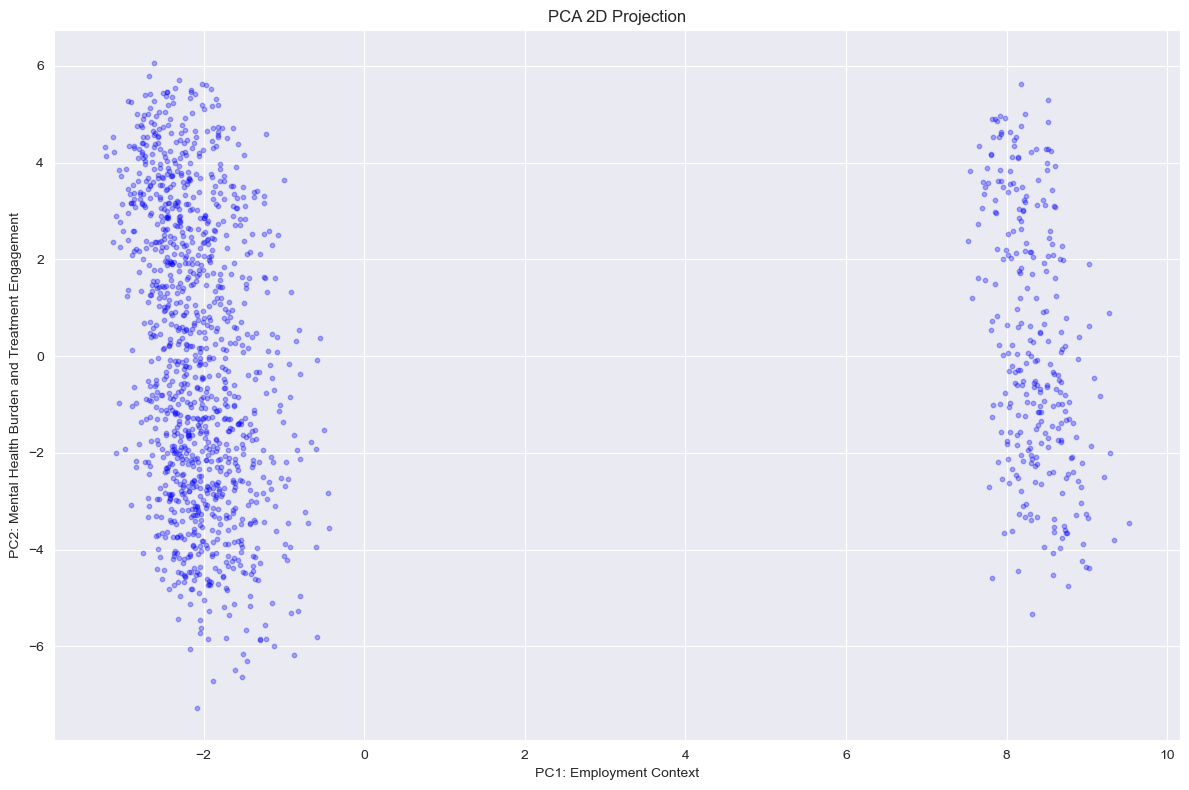

In [95]:
plt.figure(figsize=(12, 8))
plt.scatter(X_pca_2d_df['PC1'], X_pca_2d_df['PC2'], alpha=0.3, s=10, color='blue')
plt.xlabel('PC1: Employment Context')
plt.ylabel('PC2: Mental Health Burden and Treatment Engagement')
plt.title('PCA 2D Projection')
plt.tight_layout()
plt.show()

It can be clearly seen that the data reveals two clearly separable groups of data, with one occupying negative PC1 values and the other - positive PC1 values. Along PC2, both cluster have similar spread. This indicates that mental health problems are distributed comparably across the two groups. 

# 6. Multidimensional Scaling 

This method was presented as the alternative approach to PCA. 

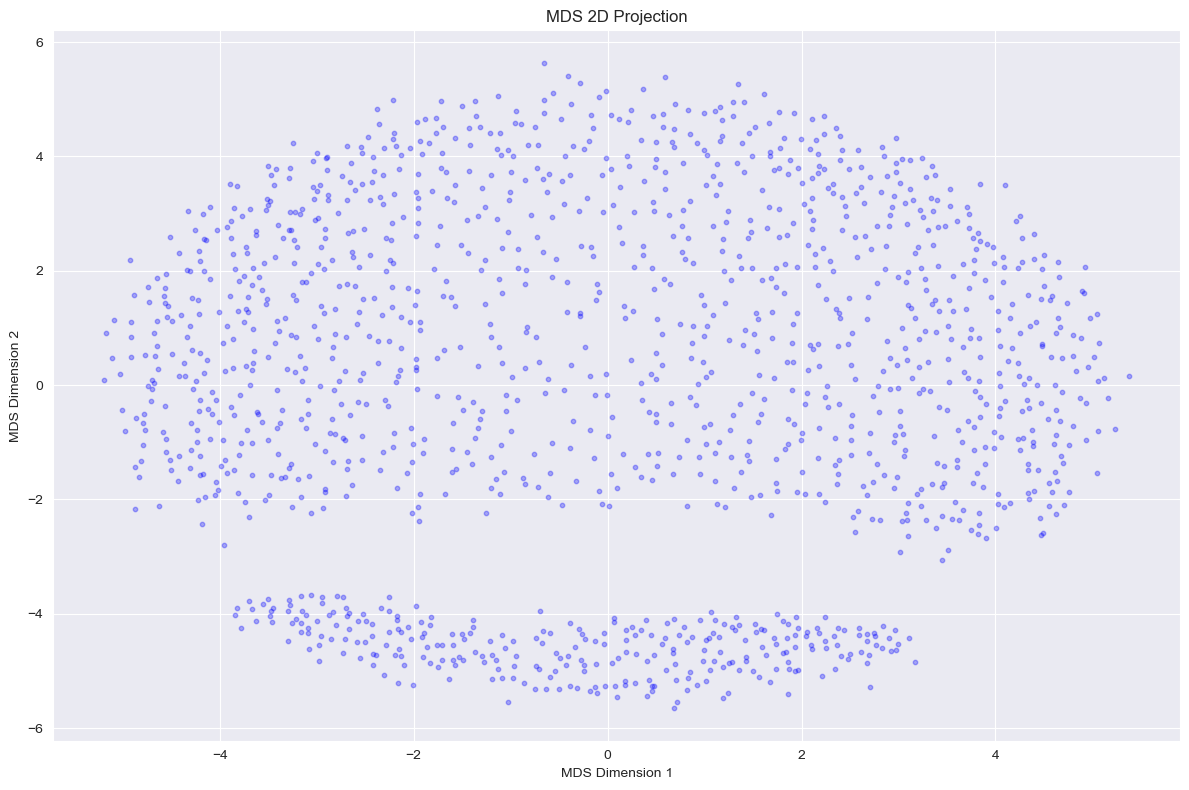

In [96]:
mds = MDS(n_components=2, random_state=42, n_init=4)
X_mds = mds.fit_transform(X_mm)

plt.figure(figsize=(12, 8))
plt.scatter(X_mds[:, 0], X_mds[:, 1], c='blue', alpha=0.3, s=10)
plt.title('MDS 2D Projection')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.tight_layout()
plt.show()

As it can be seen in the plot, the data is separated, with one cluster being more concentrated in the lower side of the plot and the other - distributed across upper region. Compared to PCA scatter plot, the separation is not as clear and pronounced. Both approaches result in 2 clusters, suggesting the number of future clusters. 

# 7. KMeans Clustering 
This method was chosen for the clustering as it is commonly used and can be easily interpreted in terms of exploratory analysis. 

To achieve the goal of finding the right number of clusters, the elbow method and the silhouette score were used. 

Both of the approaches were plotted below. 

In [97]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10,)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

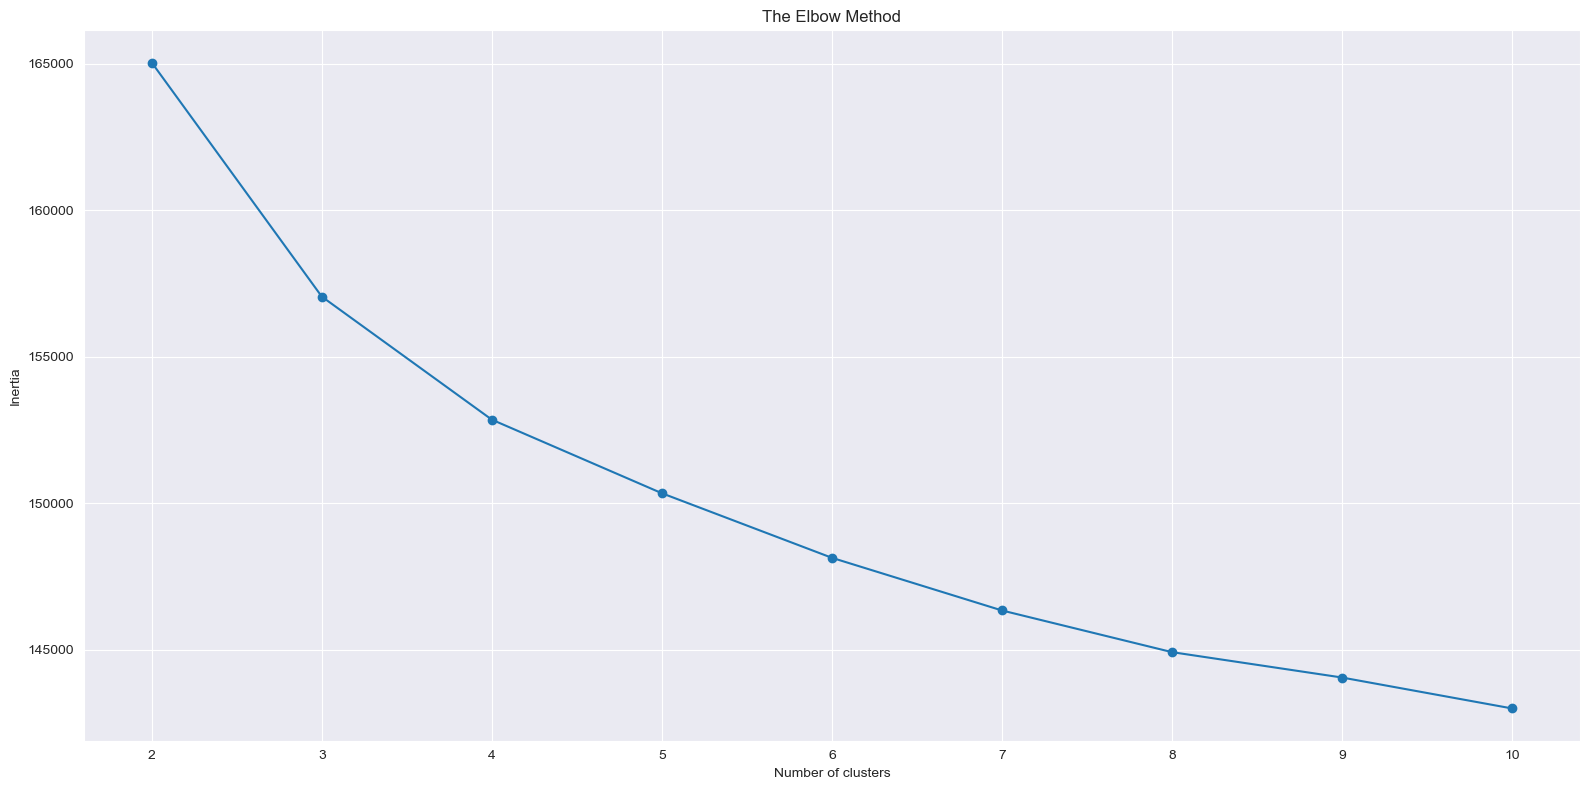

In [98]:
plt.figure(figsize=(16,8))
plt.plot(k_range, inertias, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

The line of the plot shows a gradual decrease of inertia. Unfortunatelly, the 'elbow' is not clearly visible, which may be a result of the high dimensionality of the data. This may be a limitation of this dataset. 

Moreover, this could also mean that there are no naturally separable clusters within the data. 

Also, the silhouette score plot was created. 

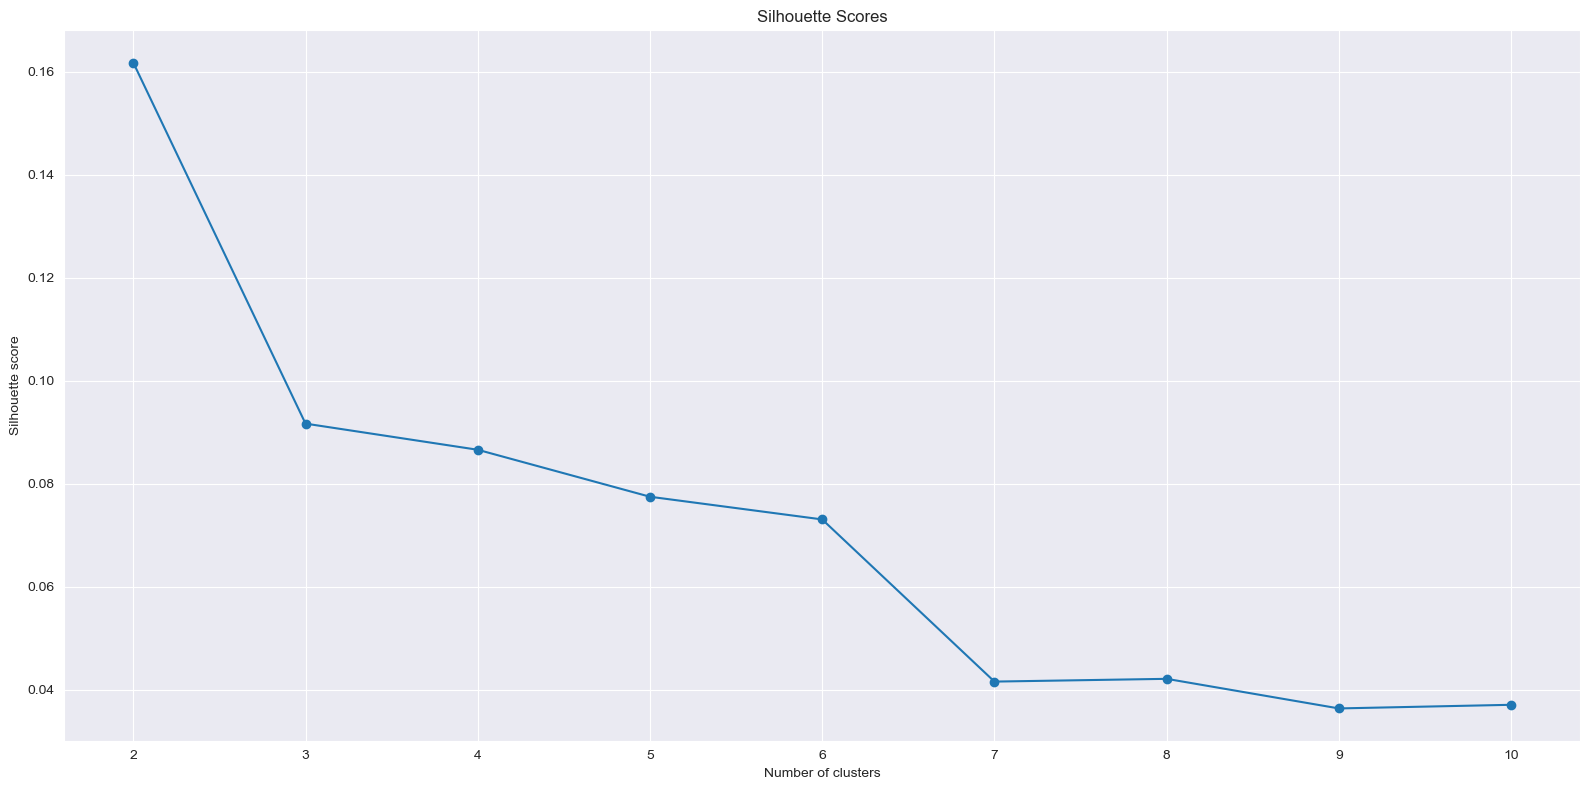

In [99]:
plt.figure(figsize=(16,8))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.show()

The silhouette score plot peaks at number of clusters = 2. 

To get proper understanding, the number of clusters was compared with the corresponding inertia and silhouette score. 

In [100]:
print("k | Inertia | Silhouette Score")
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"k={k} | {inertia:.1f} | {sil:.4f}")

k | Inertia | Silhouette Score
k=2 | 165036.5 | 0.1618
k=3 | 157052.6 | 0.0917
k=4 | 152854.5 | 0.0866
k=5 | 150344.3 | 0.0775
k=6 | 148141.6 | 0.0731
k=7 | 146345.0 | 0.0416
k=8 | 144923.0 | 0.0421
k=9 | 144057.0 | 0.0363
k=10 | 143002.0 | 0.0371


Based on these findings and the plots above, the best choice for clustering is k=2, as it has the best silhouette score, even though it is relativelly small. 

Moreover, the KMeans model was created with number of clusters = 2. Also, the labels of the clusters were obtained. 

In [101]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_pca)
labels = kmeans.labels_

print("Cluster sizes:")
print(pd.Series(labels).value_counts())

Cluster sizes:
1    1142
0     286
Name: count, dtype: int64


These labels correspond to the employment status: cluster 1 indicating the employed people, and cluster 0 indicating self-employed respondents. This was further confirmed in the cluster visualisation section.

In [102]:
# add cluster labels back to original dataframe
mh_df_original = mh_df.copy()
mh_df_original['cluster'] = labels

In [103]:
colours2 = ['#2768F5' if l == 0 else '#F54927' for l in labels]

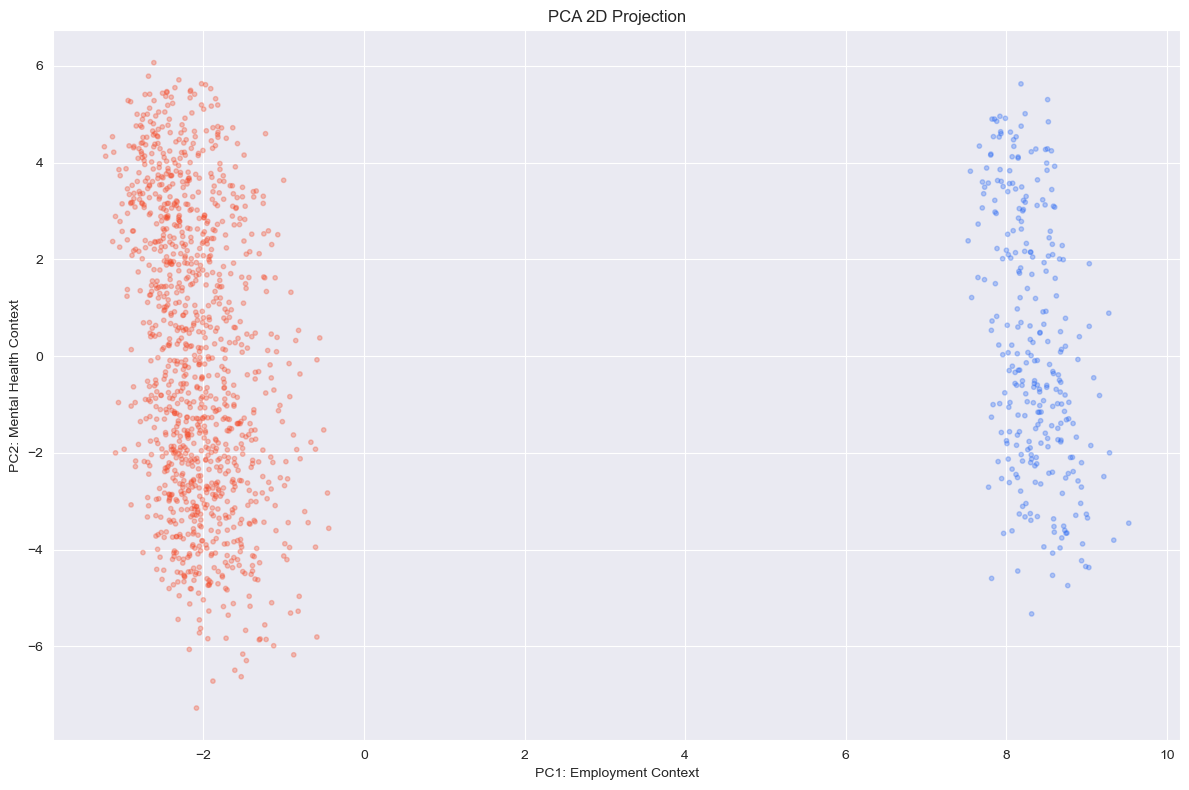

In [104]:
plt.figure(figsize=(12, 8))
plt.scatter(X_pca_2d_df['PC1'], X_pca_2d_df['PC2'], c=colours2, alpha=0.3, s=10)
plt.xlabel('PC1: Employment Context')
plt.ylabel('PC2: Mental Health Context')
plt.title('PCA 2D Projection')
plt.tight_layout()
plt.show()

This PCA scatter plot shows a clear separation between the identified clusters along PC1. Cluster 0 representing self-employed respondents (blue) is concentrated on right side of the plot with the positive values. Cluser 1 representing employed people (red), occupies negative values of PC1. Across PC2 axis, both components are spread comparably, indicating presence of mental health issues across different job types. 

# 8. Cluster Visualisation 
In the following section, a couple of plots were created, such as:
- number of respondent per cluster
- cluster proportion across multiple dimenstions, such as mental health diagnosis and professional treatment
- gender distribution per cluster 
- age distribution per cluster 

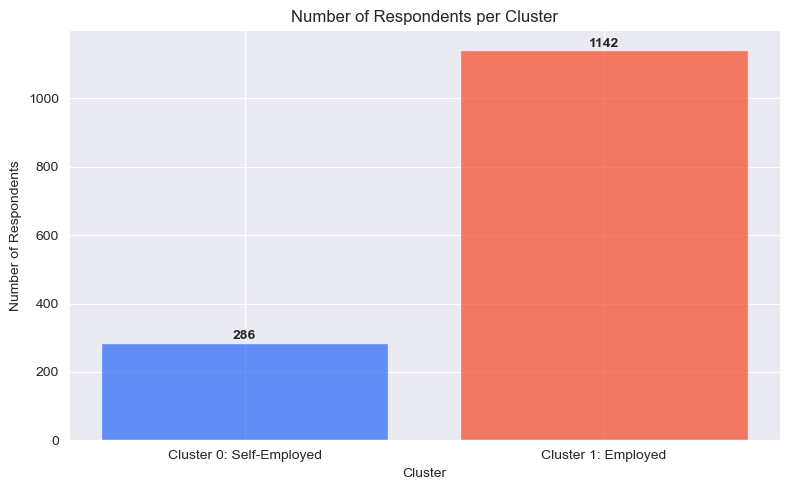

In [105]:
cluster_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(['Cluster 0: Self-Employed', 'Cluster 1: Employed'], cluster_counts.values, color=['#2768F5', '#F54927',], alpha=0.7)
plt.title('Number of Respondents per Cluster')
plt.ylabel('Number of Respondents')
plt.xlabel('Cluster')

for i, v in enumerate(cluster_counts.values):
    plt.text(i, v+10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

The data is clearly divided into two different clusters, one with number of respondents 286 and the other - 1142. This gives the proportion of 20 to 80%, indicating imbalance, which reflects the survey population.  

Additionally, the other important columns were checked whether they are worth comparing agains the clustering. 

In [106]:
mh_df_original.columns.to_list()

['Are you self-employed?',
 'How many employees does your company or organization have?',
 'Is your employer primarily a tech company/organization?',
 'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:',
 'Do you have previous employers?',
 'Have your previous employers provided mental health benefits?',
 'Were you aware of the options for mental health care provided by your previous employers?',
 'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?',
 'Did your previous employers provide resources to learn more about mental health issues and how to seek help?',
 'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?',
 'Do you think that discussing a mental health disorder with previous employers would have negative consequences?',
 'Do you think that discussing a p

After short analysis, the columns below were chosen for a visual analysis. 

In [107]:
columns_to_plot = ['Are you self-employed?', 
                   'Have you been diagnosed with a mental health condition by a medical professional?_Yes',
                   'Do you currently have a mental health disorder?_Yes',
                   'Have you ever sought treatment for a mental health issue from a mental health professional?',
                   'Have you had a mental health disorder in the past?_Yes',
                   'Would you feel comfortable discussing a mental health disorder with your coworkers?_Yes',
                   'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?_Yes',
                   'Do you feel that being identified as a person with a mental health issue would hurt your career?_Yes, I think it would']

short_names_ctp = ['Employment Status', 
                   'Diagnosed',
                   'Current mental disorder', 
                   'Treated professionally', 
                   'Past mental disorder', 
                   'Comfortable with coworkers', 
                   'Comfortable with supervisor(s)',
                   'Negative effect on career']

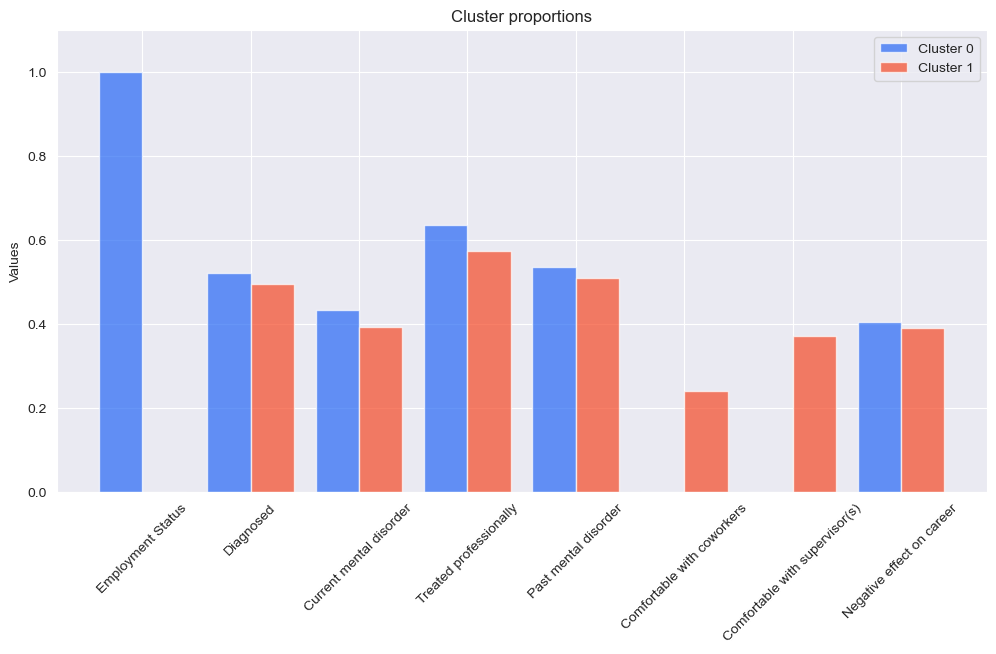

In [108]:
w, x = 0.4, np.arange(len(short_names_ctp))

cluster_0_prop = []
cluster_1_prop = []

for col in columns_to_plot:
    cluster_0_prop.append(mh_df_original[mh_df_original['cluster']==0][col].mean())
    cluster_1_prop.append(mh_df_original[mh_df_original['cluster']==1][col].mean())

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x - w/2, cluster_0_prop, width=w, label='Cluster 0', color='#2768F5', alpha=0.7)
ax.bar(x + w/2, cluster_1_prop, width=w, label='Cluster 1', color='#F54927', alpha=0.7)

ax.set_xticks(x)
plt.xticks(rotation=45)
ax.set_xticklabels(short_names_ctp)
ax.set_ylabel('Values')
ax.set_title('Cluster proportions')
ax.legend()
ax.set_ylim(0, 1.1)
plt.show()

The plot above show a proportion of cluster in each column. 
Self-employed respondents show higher rates in the mental health dimension, as well as professional treatment, and having negetive effec on career. 
Within the workplace relationships the plots are equal 0, as the questions likely do not apply to them. 
The employment status shows only the self-employed bar, as it is based on the mean of the cluster, which is 1 (as 1 indicates yes). The mean of cluster 1 is in this case 0. 
Also, the plots showing the comfort of speaking about mental health issues with coworkers and supervisors are present only for cluster 1, which is not surprising, as self-employed people tent to have no supervisors or coworkers. 

In the following step, the gender column was revieved. This column must be created one more time since all of the gender values were encoded as the dummies variable before. 

In [109]:
gender_cols = ['Gender_female', 'Gender_male', 'Gender_nonbinary', 'Gender_other', 'Gender_unknown']
mh_df_original['Gender'] = mh_df[gender_cols].idxmax(axis=1).str.replace('Gender_', '')

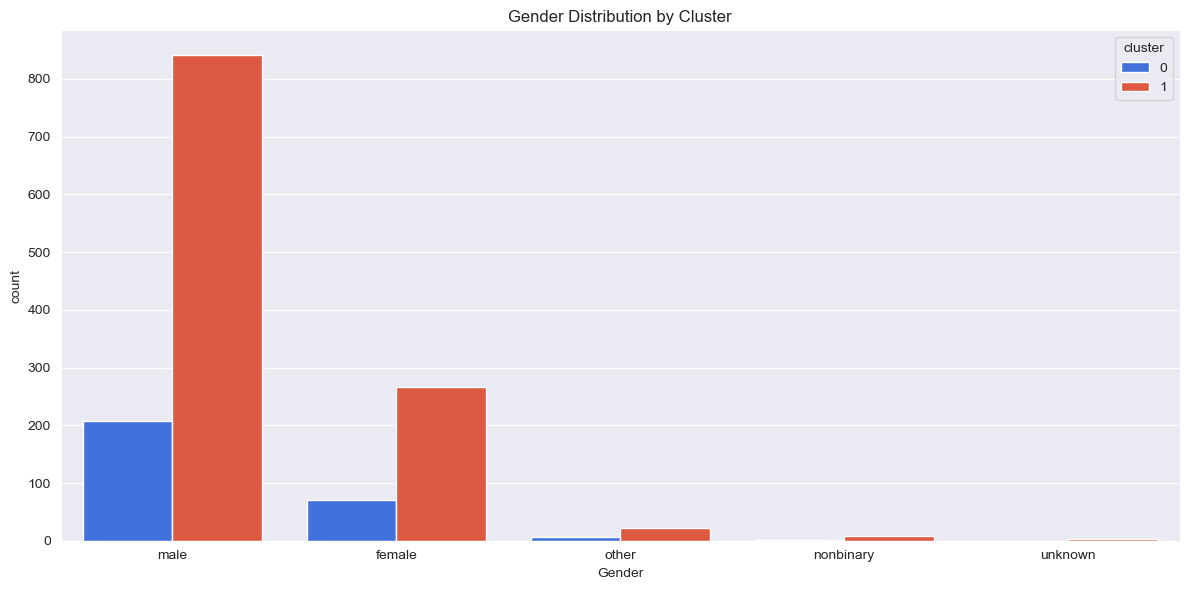

In [110]:
plt.figure(figsize=(12, 6))
sns.countplot(data=mh_df_original, x='Gender', hue='cluster', palette={0: '#2768F5', 1: '#F54927'}) # maybe delete hue cluster
plt.title('Gender Distribution by Cluster')
plt.tight_layout()
plt.show()

Both clusters are male dominated, which reflects the gender proportion of the dataset. The proportions are similar across genders, suggesting that gender is not a primary differentiator across employment context.

Additionally, the age distribution agains each cluster was plotted. 

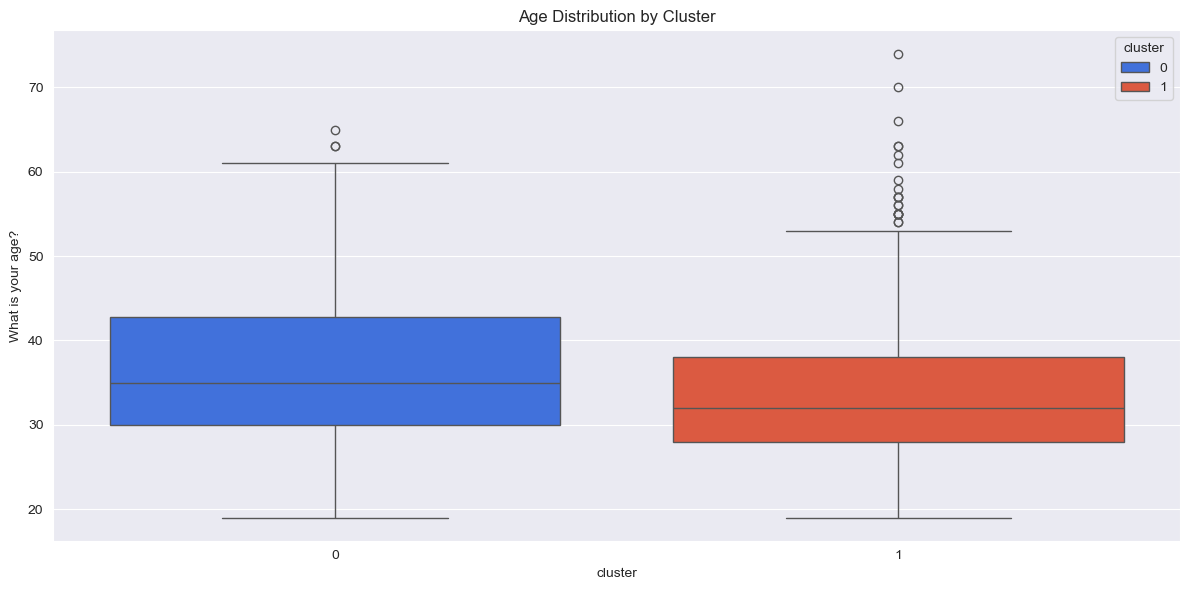

In [111]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=mh_df_original, x='cluster', y='What is your age?', hue='cluster', palette={0: '#2768F5', 1: '#F54927'})
plt.title('Age Distribution by Cluster')
plt.tight_layout()
plt.show()

It can be noticed that the self-employed people are slightly older. This was also proven below in the descriptive statistic section. 

# 9. Descriptive statistics 
A short descriptive statistic section was created, with mean, standard deviation, minimum and maximum value per column based on the clusters to provide a proper summary and show key differences between the clusters. 

In [112]:
descriptive_stats = mh_df_original.groupby('cluster').agg({
    'What is your age?': ['mean', 'std', 'min', 'max'],
    'Are you self-employed?': 'mean',
}).round(3)

descriptive_stats

What is your age?                Are you self-employed?
                     mean    std min max                   mean
cluster                                                        
0                  36.881  8.979  19  65                    1.0
1                  33.386  7.694  19  74                    0.0

As seen also in the plot above, people that are self-employed tend to be slightly older than the repsondents of the employed group.

Further, a stigma score was created - a score that represents the 'fear' associated with revealing the mental health state and its consequences. 

In [113]:
mh_df_original['stigma score'] = (
    mh_df_original['Do you feel that being identified as a person with a mental health issue would hurt your career?_Yes, I think it would'] +
    mh_df_original['Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?_Yes, I think they would']
) / 2

print(mh_df_original.groupby('cluster')['stigma score'].mean().round(3))

cluster
0    0.369
1    0.330
Name: stigma score, dtype: float64


As above, both clusters have a comparable stigma score, with the stigma score of cluster 0 being slightly higher, suggesting presence of fear of consequences as the result of revealing mental health state, regardless of the employment type. Moreover, it must be noted that there is cluster imbalance present within the data, which also affects the results. 

In [114]:
print(mh_df_original.groupby('cluster')[[
    'Would you feel comfortable discussing a mental health disorder with your coworkers?_Yes',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?_Yes'
]].mean().round(3))

         Would you feel comfortable discussing a mental health disorder with your coworkers?_Yes  \
cluster                                                                                            
0                                                     0.00                                         
1                                                     0.24                                         

         Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?_Yes  
cluster                                                                                                      
0                                                    0.000                                                   
1                                                    0.372                                                   


As mentioned in the cluster analysis section, the self-employed people tend to work alone - this explains that the mean score of these respondents is 0. Across emplyoed people, people would rather feel not comfortable discussing their mental health issues with their coworker and supervisors. 

Finally, the size of the company and the mental health was checked.

In [115]:
print(mh_df_original[mh_df_original['cluster']==1].groupby(
    'How many employees does your company or organization have?'
)['Do you currently have a mental health disorder?_Yes'].mean().round(3))

How many employees does your company or organization have?
1    0.317
2    0.346
3    0.435
4    0.401
5    0.300
6    0.427
Name: Do you currently have a mental health disorder?_Yes, dtype: float64


The number 3 indicates the company size of 26 to 100 employees. Within this size of the company, mental health issues are most present. There is no relation between the company size and mental health state, as small companies reach similar scores as the big ones. 

The presence of mental health disorder per cluster was checked, as well as the seeking of professional mental health treatment. 

In [116]:
print(mh_df_original.groupby('cluster')[[
    'Do you currently have a mental health disorder?_Yes',
    'Have you ever sought treatment for a mental health issue from a mental health professional?'
]].mean().round(3))

         Do you currently have a mental health disorder?_Yes  \
cluster                                                        
0                                                    0.434     
1                                                    0.394     

         Have you ever sought treatment for a mental health issue from a mental health professional?  
cluster                                                                                               
0                                                    0.636                                            
1                                                    0.574                                            


These findings suggest that the mental health issues are slightly more present across self-employed people. Moreover, both groups seek professionaly health treatment. It also shows that more people sought help than actually have mental health issues. 

Lastly, the presence of particular disorders was obtained for each cluster. 

In [117]:
print(mh_df_original.groupby('cluster')[[
    'Mood Disorder Depression, Bipolar Disorder, etc',
    'Anxiety Disorder Generalized, Social, Phobia, etc',
    'Attention Deficit Hyperactivity Disorder',
    'Post-traumatic Stress Disorder',
    'Obsessive-Compulsive Disorder']].mean().round(3))

         Mood Disorder Depression, Bipolar Disorder, etc  \
cluster                                                    
0                                                    0.0   
1                                                    0.0   

         Anxiety Disorder Generalized, Social, Phobia, etc  \
cluster                                                      
0                                                      0.0   
1                                                      0.0   

         Attention Deficit Hyperactivity Disorder  \
cluster                                             
0                                           0.105   
1                                           0.090   

         Post-traumatic Stress Disorder  Obsessive-Compulsive Disorder  
cluster                                                                 
0                                 0.059                          0.024  
1                                 0.046                          0.029  


The analysis provided that mood disorder depression / bipolar disorder and anxiety disorder do not appear within both clusters. Moreover, ADHD and post-traumatic stress disorder are slightly more present across self-employed respondents, compared to traditionally employed people. Obsessive-Compulsive Disorder is slightly more present across employed respondents. This values may indicate the connection between ADHD and self-employment, as well as OCD and traditional work.

# 10. Conclusions 
In this project, the OSMI Mental Health dataset was used to perform feature engineering, and unsupervised learning algorithm to find clusters within the data. The work included data exploration, feature engineering, such as dealing with the missing values and textual feature extraction. To reduce the dimensionality of the dataset, PCA was applied as the primary method. The analysis allowed to produce the following findings: 
- Cluster 0 representing self-employed people, that are characterised by being slightly older, with higher percentage of the diagnosed mental health issues and a fear of being treated differently based on their mental health state. 
- Cluster 1 that represents traditionally employed people, that are slightly younger than respondents from cluster 0. They also tend to have slightly lower percentage of the diagnosis of the mental health issues, and their fear of being treated differently based on their mental health states is also slightly lower. 

These findings suggest the following implementation for HR in the mental health program:
- reducing stigmatisation related to mental health issues in the workplace
- raising awareness about mental health treatment options 
- improving psychological safety across coworkers and supervisors 
- creating regular mental health check ups
- creating privacy protection to reduce career-related fear regarding mental health issues  

Additionally, it must be noted that the silhouette score for k=2 was 0.1618, which reflects the high dimensionality and complexity of the mental health issues across tech workplaces. 

# 11. Limitations 
- the dataset does not reflect current mental health state within companies as it was constructed in 2016 
- the dataset is mainly US based and male based, which limits the generalisability 
- filling up the missing values with the 'Unknown' category while preserving information, may have introduced bias
- the silhouette score reflects high dimensionality of the data and suggest that there are no naturally separable clusters within the dataset, as well as that the clusters should be interpreted broadly
- TF-IDF vectorisation does not preserve semantic of the text 

# 12. Future Work 
- another clustering approaches could be considered, such as DBSCAN, hierarchical clustering, or Gaussian mixture model
- NLP could be used instead of TF-IDF vectorisation to extract not only features but also the semantic of the text, enriching the analysis
- using more modern dataset to get proper insight of current mental health problems within workplaces 